# Modelo de Incorporación de Generación *Behind-the-Meter* (BtM) en el Planeamiento de la Demanda del SIN (2026–2040)

Este cuaderno implementa el marco cuantitativo y reproducible para evaluar el impacto de la autogeneración solar fotovoltaica (*Behind-the-Meter*, BtM) y los sistemas de almacenamiento de energía con baterías (BESS) sobre el planeamiento de la demanda eléctrica del Sistema Interconectado Nacional (SIN) de Colombia para el horizonte 2026–2040.

### Estructura del modelo
1. **Parámetros y fuentes documentales:** Registro centralizado de fuentes regulatorias y técnicas (UPME, CREG, XM, DANE, IDEAM, APPA).
2. **Demanda base y ensamble econométrico:** Estimación combinada ponderada UPME (0,56 VAR-X / 0,22 VAR / 0,22 VECM) sobre 132 observaciones mensuales reales (2014–2024).
3. **Desagregación horaria y recurso solar:** Simulación matricial de 8.760 horas/año con perfiles de carga del SIN y geometría solar regional para 5 áreas eléctricas.
4. **Difusión tecnológica de Bass:** Calibración no lineal de trayectorias de adopción bajo escenarios tendencial (UPME, 7.182 MWp) y acelerado (PNUMA, 20.677 MWp).
5. **Almacenamiento BESS (*Power Nodes*):** Despacho horario bajo balance energético cerrado para mitigación de curva de pato y recorte de punta nocturna.
6. **Flexibilidad y regulación:** Índices de rampa horaria ($I_{\text{flex}}$, $I_{\text{flex2}}$), cruce del umbral regulatorio del 4% (CREG 901 099 de 2024) e incremento del Costo Unitario ($\Delta CU$).
7. **Finanzas del prosumidor y compensación:** Indicadores LCOE, NPV y período de retorno; evaluación comparativa de *Net Metering* (Resolución CREG 174) frente a *Net Billing*.
8. **Validación y pruebas de consistencia:** Pruebas formales P1 (energía), P2 (adopción), P3 (balance horario) y P4 (cierre de ciclo SoC).

### Instrucciones de uso
* **Ejecución:** Ejecutar las celdas secuencialmente de inicio a fin.
* **Insumos:** Requiere el archivo `Dataset_Final_4_Series_2014_2024.csv` en el directorio de trabajo.
* **Salidas:** Las 18 figuras (.png) y las tablas maestras (`escenarios_btm.csv`, `resultados_btm.xlsx` y `anexoC_statsmodels.txt`) se exportan automáticamente al directorio `salidas/`.

In [1]:
# =============================================================
# §0. Configuración del entorno
# =============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from scipy.optimize import brentq, curve_fit
import warnings, json, os, textwrap

warnings.filterwarnings("ignore")
np.random.seed(20260829)

plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

OUT = "salidas"
os.makedirs(OUT, exist_ok=True)

print(f"Entorno configurado exitosamente (NumPy {np.__version__}, Pandas {pd.__version__}).")
print(f"Directorio de exportación de resultados: '{OUT}/'.")


Entorno configurado exitosamente (NumPy 2.3.5, Pandas 2.3.3).
Directorio de exportación de resultados: 'salidas/'.


---
## §1. Parámetros del modelo

Todos los valores provienen de las fuentes cargadas en el proyecto. El diccionario `FUENTES` mantiene la
trazabilidad exigida para los anexos del informe.


In [2]:
# =============================================================
# §1.1 Trazabilidad de fuentes
# =============================================================
FUENTES = {
    "UPME_DEM":  "UPME, Proyecciones de Demanda de Energía Eléctrica y Potencia Máxima, Rev. Julio 2026 (VRF)",
    "UPME_PGT":  "UPME, Plan de Expansión de Referencia Generación–Transmisión 2016–2030 (Dic. 2016)",
    "CREG_901":  "CREG, Documento 901 099 de 2024 (Comunidades Energéticas: AGRC y GDC)",
    "CREG_174":  "CREG, Resolución 174 de 2021 (AGPE, AGGE y Generación Distribuida)",
    "APPA_2025": "APPA/UNEF, Informe de Autoconsumo Fotovoltaico y Almacenamiento 2025 (España)",
    "VARGAS":    "Vargas-Forero et al. (2025), Benchmarking ARIMA/Prophet/LSTM demanda horaria SIN (doc. 1920720030_0)",
    "LEY_1715":  "Ley 1715 de 2014, modificada por Ley 2099 de 2021",
    "HEUSSEN":   "Heussen, Koch, Ulbig & Andersson (2010), 'Energy storage in power system operation: "
                 "The Power Nodes modeling framework', IEEE PES ISGT Europe, pp. 1-8 "
                 "[fuente citada por la UPME en el Plan GT 2016-2030, nota 11, p.188]",
    "ULBIG":     "Ulbig & Andersson (2014), 'Analyzing Operational Flexibility of Electric Power Systems', "
                 "Int. J. of Electrical Power & Energy Systems 64, 1155-1164",
    "CASTANO":   "Castaño V., Elkin (1994), 'Combinación de pronósticos y variables predictoras con error', "
                 "Revista Lecturas de Economía No. 41, Universidad de Antioquia "
                 "[fundamento citado por la UPME para el modelo combinado]",
    "ERDENER":   "Cakir Erdener, Feng, Doubleday, Florita & Hodge (2022), 'A review of behind-the-meter "
                 "solar forecasting', Renewable and Sustainable Energy Reviews 160, 112224",
    "REZAEI":    "Rezaeimozafar, Monaghan, Barrett & Duffy (2022), 'A review of behind-the-meter energy "
                 "storage systems in smart grids', Renewable and Sustainable Energy Reviews 164, 112573",
    "UPME_MET":  "UPME (2020), Metodología para Proyecciones de Demanda de Energía Eléctrica y Gas Natural",
    "OLIVEIRA":  "De Oliveira-De Jesus, Salas D. & Yusta (2026), 'Model for optimal sizing of Photovoltaic "
                 "and Battery Energy Storage Systems considering an efficient scheme for contracted power "
                 "capacity', Journal of Energy Storage 180, 124014",
}

def cite(*claves):
    """Devuelve la referencia formateada de una o más fuentes."""
    return " | ".join(FUENTES[k] for k in claves)

def theil(pred, real):
    """
    Descompone el MSE en sesgo (B), modelo (M) y aleatorio (R). B + M + R = 1.
    Criterio de evaluación oficial de la UPME (Metodología 2020): B -> 0 y R -> 1.
    """
    p = np.asarray(pred, float); a = np.asarray(real, float)
    mse = np.mean((p - a) ** 2)
    if mse == 0:
        return {"MSE": 0.0, "RMSE": 0.0, "B": 0.0, "M": 0.0, "R": 1.0, "MAPE": 0.0}
    sp, sa = p.std(), a.std()
    r = np.corrcoef(p, a)[0, 1] if sp > 0 and sa > 0 else 0.0
    return {"MSE": mse, "RMSE": np.sqrt(mse),
            "B": (p.mean() - a.mean()) ** 2 / mse,
            "M": (sp - r * sa) ** 2 / mse,
            "R": (1 - r ** 2) * sa ** 2 / mse,
            "MAPE": np.mean(np.abs(p / a - 1))}


print(f"Trazabilidad documental: {len(FUENTES)} fuentes regulatorias y técnicas registradas.")


Trazabilidad documental: 14 fuentes regulatorias y técnicas registradas.


In [3]:
# =============================================================
# §1.2 Parámetros numéricos (dataclass central)
# =============================================================

@dataclass
class Parametros:
    # --- Horizonte -------------------------------------------------
    anio_ini: int = 2026
    anio_fin: int = 2040

    # --- Anclas de demanda bruta, GWh/año  [UPME_DEM] --------------
    # Demanda Energética Bruta (SIN + Grandes Consumidores Especiales + Movilidad Eléctrica)
    anclas_energia: dict = field(default_factory=lambda: {2026: 92_511.0, 2030: 105_675.0, 2040: 140_798.0})

    # --- Anclas de potencia máxima NETA con GD_UPME, MW  [UPME_DEM, p.65]
    anclas_potencia: dict = field(default_factory=lambda: {2026: 12_832.0, 2030: 13_802.0, 2040: 17_343.0})

    # --- Trayectorias de capacidad BtM instalada, MW  [UPME_DEM, Gráfica 24, p.47]
    anclas_gd_upme:  dict = field(default_factory=lambda: {2026: 1_200.0, 2030: 3_331.0, 2040: 7_182.0})
    anclas_gd_pnuma: dict = field(default_factory=lambda: {2026: 7_424.0, 2030: 12_000.0, 2040: 20_677.0})

    # --- Recurso solar --------------------------------------------
    cf_solar_upme: float = 0.20      # factor de planta constante asumido por la UPME
    # Desagregación de pérdidas FV según De Oliveira-De Jesus et al. (2026): total 17,76%
    perdidas_modulo: float = 0.1400  # conversión del módulo, suciedad, temperatura, mismatch
    perdidas_inversor: float = 0.0376  # inversor FV
    ilr: float = 1.60                # Inverter Loading Ratio = P_inst_DC / P_inversor_AC

    @property
    def perdidas_bos(self) -> float:
        """Pérdidas totales del sistema FV (17,76% en el caso de referencia)."""
        return 1 - (1 - self.perdidas_modulo) * (1 - self.perdidas_inversor)

    # --- Ponderaciones del modelo econométrico combinado ------------
    # Vigentes (ejercicio 2023, usado en Rev. Julio 2026) [UPME_DEM, p.44, nota 36]
    w_var_exog:  float = 0.56
    w_var_endog: float = 0.22
    w_vec:       float = 0.22
    # Vigentes en el Plan GT 2016-2030 (p.53), para comparación histórica.
    # Se seleccionaron con los criterios de Akaike, Schwarz y log-verosimilitud conjunta.
    w_2016: dict = field(default_factory=lambda: {"VAR_endog": 0.42, "VAR_exog": 0.39, "VEC": 0.19})

    # Banda de confianza de los escenarios alto/bajo (Plan GT 2016-2030, p.53)
    z_banda: float = 1.96            # 95% de confianza

    # --- Enmascaramiento solar (load masking) [ERDENER] -------------
    # Capacidad BtM YA instalada en el año base, cuyo autoconsumo ya está
    # descontado de la serie histórica de XM medida en frontera comercial.
    cap_btm_base_mw: float = 1_200.0   # = GD_UPME en 2026

    # --- Correlaciones históricas de drivers con la potencia pico [UPME_DEM, p.43]
    corr_pib:  float = 0.4264
    corr_pob:  float = 0.1206
    corr_temp: float = 0.3408

    # --- Composición del parque BtM (benchmark España) [APPA_2025] --
    frac_comercial_industrial: float = 0.72
    frac_residencial:          float = 0.28

    # --- Almacenamiento BtM ----------------------------------------
    # Benchmark España 2025: 339 MWh acumulados sobre 9.590 MWp instalados
    ratio_mwh_por_mwp_esp: float = 339.0 / 9_590.0
    # Eficiencias y límites según De Oliveira-De Jesus et al. (2026), Apéndice C
    eta_carga:    float = 0.9629     # eta_load (Power Nodes) / eta_c del paper
    eta_descarga: float = 0.9626     # eta_gen  (Power Nodes) / eta_d del paper
    c_rate:       float = 0.50       # potencia máx. = c_rate * capacidad [MW/MWh]; rango del paper 0,1–2,0
    soc_min:      float = 0.05       # beta_min, equivale a DoD = 90%
    soc_max:      float = 0.95       # beta_max
    # v(x) en la notación Power Nodes: PÉRDIDAS DE ALMACENAMIENTO (no es xi)
    perdidas_almacenamiento_h: float = 0.00002

    # --- Regulación ------------------------------------------------
    umbral_energia_regulado: float = 0.04    # 4% de la energía del mercado regulado [CREG_901]
    umbral_potencia_gw:      float = 1.20    # 1,2 GW equivalentes al 4%          [CREG_901]
    sensibilidad_cu:         float = 2.9167  # ΔCU_N1 [%] ≈ 2.9167 * P_inst [GW]  [CREG_901]
    frac_mercado_regulado:   float = 0.68    # participación del regulado en la demanda total (supuesto)
    limite_inyeccion_min:    float = 0.50    # inyección ≤ 50% de la demanda mínima diaria [CREG_174]

    # --- Dimensionamiento y operación del sistema -------------------
    # Fracción del consumo ANUAL del usuario BtM que cubre su propia FV.
    # Determina cuántos usuarios hay detrás de una capacidad instalada dada y,
    # por tanto, cuánto excedente se produce al mediodía.
    cobertura_btm: float = 0.80
    # Mínimo técnico del parque despachable (must-run hidráulico + térmico),
    # como fracción de la potencia máxima bruta del año. Por debajo de este
    # nivel la inyección BtM debe recortarse.
    minimo_tecnico_pu: float = 0.35

    # --- Flexibilidad ----------------------------------------------
    # Capacidad de rampa horaria del parque despachable, como fracción de la potencia máxima del año
    rampa_despachable_pu: float = 0.20

    @property
    def anios(self):
        return np.arange(self.anio_ini, self.anio_fin + 1)

P = Parametros()
print(f"Horizonte de planeamiento: {P.anio_ini}–{P.anio_fin} ({len(P.anios)} años)")
print(f"Ponderaciones ensamble UPME: VAR-X={P.w_var_exog:.2f}, VAR={P.w_var_endog:.2f}, VEC={P.w_vec:.2f} (Total = {P.w_var_exog + P.w_var_endog + P.w_vec:.2f})")
print(f"Ratio de almacenamiento benchmark España (2025): {P.ratio_mwh_por_mwp_esp:.4f} MWh/MWp")


Horizonte de planeamiento: 2026–2040 (15 años)
Ponderaciones ensamble UPME: VAR-X=0.56, VAR=0.22, VEC=0.22 (Total = 1.00)
Ratio de almacenamiento benchmark España (2025): 0.0353 MWh/MWp


In [4]:
# =============================================================
# §1.3 Áreas eléctricas y recurso solar regional
# =============================================================
# Participación por área eléctrica a partir de la demanda mensual promedio (GWh-mes) [UPME_DEM]
# y latitud representativa para el modelo de posición solar.

AREAS = pd.DataFrame({
    "area":     ["Caribe", "Oriente", "Suroccidente", "Antioquia", "Nordeste"],
    "gwh_mes":  [1877.37,  1768.34,   1289.37,        929.83,      811.07],
    "latitud":  [10.40,     4.90,      3.45,           6.25,        7.10],
    "longitud": [-74.90,  -74.10,    -76.53,         -75.57,      -73.12],
    # Índice de claridad medio (kt): mayor en el Caribe/Guajira, menor en zonas andinas nubosas
    "kt":       [0.58,      0.47,      0.45,           0.44,        0.50],
})
AREAS["peso"] = AREAS["gwh_mes"] / AREAS["gwh_mes"].sum()
AREAS = AREAS.set_index("area")

display(AREAS.round(4))
print(f"\nLatitud media ponderada por demanda: {(AREAS.latitud * AREAS.peso).sum():.2f}°N")



Latitud media ponderada por demanda: 6.62°N


,gwh_mes,latitud,longitud,kt,peso
area,,,,,
Caribe,1877.37,10.40,-74.90,0.58,0.2812
Oriente,1768.34,4.90,-74.10,0.47,0.2649
Suroccidente,1289.37,3.45,-76.53,0.45,0.1931
Antioquia,929.83,6.25,-75.57,0.44,0.1393
Nordeste,811.07,7.10,-73.12,0.50,0.1215


---
## §2. Módulo A — Demanda base y modelo econométrico

### §2.1 Reconstrucción de la trayectoria anual a partir de las anclas UPME

La UPME publica la proyección completa año a año; aquí se reconstruye por **interpolación log-lineal por tramos**
(equivalente a asumir una tasa de crecimiento compuesta constante dentro de cada tramo entre anclas), lo cual
preserva exactamente los valores oficiales en 2026, 2030 y 2040.

$$X(t) = X(t_0)\left(\frac{X(t_1)}{X(t_0)}\right)^{\frac{t-t_0}{t_1-t_0}}, \qquad t_0 \le t \le t_1$$


In [5]:
# =============================================================
# §2.1 Interpolación log-lineal por tramos entre anclas
# =============================================================

def interpolar_anclas(anclas: dict, anios) -> pd.Series:
    """Interpolación log-lineal (CAGR por tramos) que respeta exactamente las anclas."""
    ax = np.array(sorted(anclas.keys()), dtype=float)
    ay = np.array([anclas[int(a)] for a in ax], dtype=float)
    anios = np.asarray(anios, dtype=float)
    # extrapolación plana con la tasa del tramo extremo más cercano
    y = np.exp(np.interp(anios, ax, np.log(ay)))
    return pd.Series(y, index=anios.astype(int))


def cagr(serie: pd.Series, a0=None, a1=None) -> float:
    a0 = a0 or serie.index.min(); a1 = a1 or serie.index.max()
    return (serie[a1] / serie[a0]) ** (1 / (a1 - a0)) - 1


demanda = pd.DataFrame(index=P.anios)
demanda["E_bruta_GWh"]   = interpolar_anclas(P.anclas_energia,  P.anios)
demanda["Pmax_UPME_MW"]  = interpolar_anclas(P.anclas_potencia, P.anios)
demanda["GD_UPME_MW"]    = interpolar_anclas(P.anclas_gd_upme,  P.anios)
demanda["GD_PNUMA_MW"]   = interpolar_anclas(P.anclas_gd_pnuma, P.anios)

# Factor de carga implícito de las series oficiales
demanda["FC_implicito"] = demanda["E_bruta_GWh"] * 1e3 / (demanda["Pmax_UPME_MW"] * 8760)

print("CAGR energía bruta 2026–2040 :", f"{cagr(demanda['E_bruta_GWh']):.2%}")
print("CAGR potencia máx. 2026–2040 :", f"{cagr(demanda['Pmax_UPME_MW']):.2%}")
print("CAGR GD_UPME 2026–2040       :", f"{cagr(demanda['GD_UPME_MW']):.2%}",
      "  (la UPME reporta 16,4% como promedio aritmético de tasas anuales, no CAGR)")
print("CAGR GD_PNUMA 2026–2040      :", f"{cagr(demanda['GD_PNUMA_MW']):.2%}",
      "  (la UPME reporta 62,5% incluyendo el salto de años previos a 2026)")
display(demanda.round(2))


CAGR energía bruta 2026–2040 : 3.05%
CAGR potencia máx. 2026–2040 : 2.18%
CAGR GD_UPME 2026–2040       : 13.63%   (la UPME reporta 16,4% como promedio aritmético de tasas anuales, no CAGR)
CAGR GD_PNUMA 2026–2040      : 7.59%   (la UPME reporta 62,5% incluyendo el salto de años previos a 2026)


,E_bruta_GWh,Pmax_UPME_MW,GD_UPME_MW,GD_PNUMA_MW,FC_implicito
2026,92511.00,12832.00,1200.00,7424.00,0.82
2027,95639.68,13067.91,1548.92,8370.93,0.84
2028,98874.16,13308.17,1999.30,9438.64,0.85
2029,102218.04,13552.83,2580.63,10642.54,0.86
2030,105675.00,13802.00,3331.00,12000.00,0.87
2031,108751.36,14120.83,3597.01,12671.03,0.88
2032,111917.27,14447.03,3884.26,13379.58,0.88
2033,115175.35,14780.76,4194.46,14127.75,0.89
2034,118528.27,15122.20,4529.42,14917.76,0.89
2035,121978.80,15471.53,4891.14,15751.95,0.90


### §2.2 Diagnóstico metodológico: Relación Energía — Potencia Máxima

La UPME deriva la potencia máxima a partir de la energía proyectada mediante la relación lineal $P_{\max} = a + bE$ (Plan de Expansión 2016–2030, §2.6). La presencia de un intercepto positivo induce un factor de carga implícito creciente a lo largo del horizonte (de 0,82 en 2026 a 0,93 en 2040), lo que fundamenta la necesidad de una simulación horaria explícita de 8.760 horas.


Regresión  Pmax = a + b*E   (hipótesis: método UPME §2.6)
  intercepto a =      3,931 MW
  pendiente  b =    0.09495 MW por GWh
  R2           =     0.9963

  Factor de carga asintótico implícito: 1.202   (IMPOSIBLE, mayor que 1,0)

Verificación contra las anclas oficiales:
  2026: regresión   12,714 MW | oficial   12,832 MW | error -0.92%
  2030: regresión   13,964 MW | oficial   13,802 MW | error +1.17%
  2040: regresión   17,299 MW | oficial   17,343 MW | error -0.25%
Diagnóstico UPME: Pmax = 3,931 + 0.09495*E (R²=0.9963). FC asintótico = 1.202.


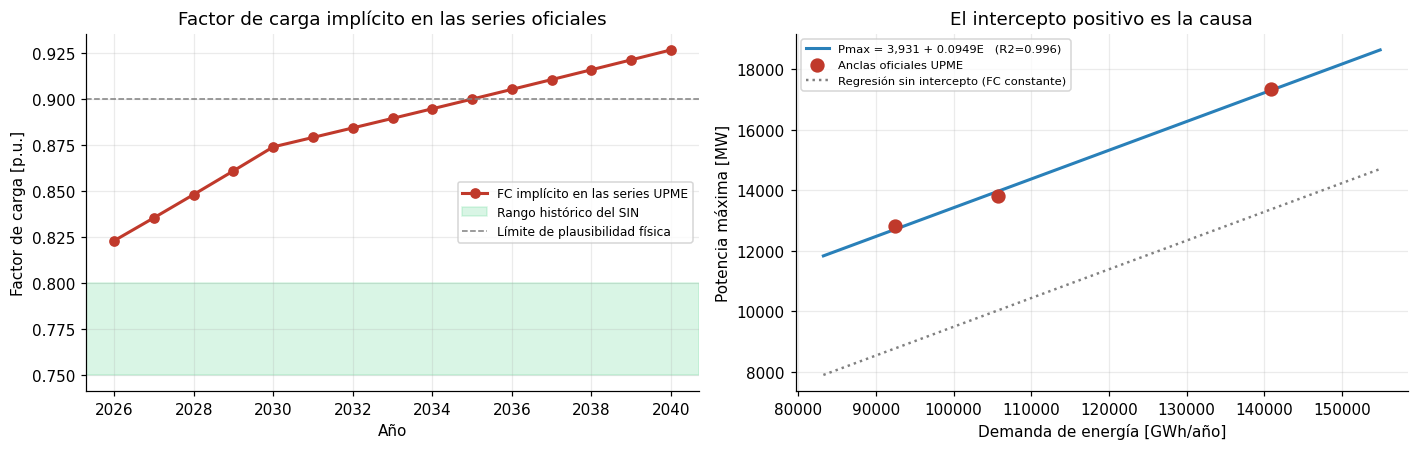

In [6]:
# =============================================================
# §2.2 Diagnóstico: ¿de dónde sale el factor de carga creciente?
# =============================================================
# Hipótesis: la UPME obtiene MW_max por regresión lineal sobre la energía
# (Plan GT 2016-2030, §2.6, p.72), no a partir de un perfil horario.

x_e = np.array([P.anclas_energia[a]  for a in sorted(P.anclas_energia)])
y_p = np.array([P.anclas_potencia[a] for a in sorted(P.anclas_potencia)])
b_reg, a_reg = np.polyfit(x_e, y_p, 1)
r2 = np.corrcoef(x_e, y_p)[0, 1] ** 2
fc_asintotico = 1000 / (8760 * b_reg)

print("Regresión  Pmax = a + b*E   (hipótesis: método UPME §2.6)")
print(f"  intercepto a = {a_reg:>10,.0f} MW")
print(f"  pendiente  b = {b_reg:>10.5f} MW por GWh")
print(f"  R2           = {r2:>10.4f}")
print(f"\n  Factor de carga asintótico implícito: {fc_asintotico:.3f}"
      f"   {'(IMPOSIBLE, mayor que 1,0)' if fc_asintotico > 1 else ''}")
print("\nVerificación contra las anclas oficiales:")
for a in sorted(P.anclas_energia):
    pred = a_reg + b_reg * P.anclas_energia[a]
    print(f"  {a}: regresión {pred:>8,.0f} MW | oficial {P.anclas_potencia[a]:>8,.0f} MW"
          f" | error {pred/P.anclas_potencia[a]-1:+.2%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
ax.plot(demanda.index, demanda["FC_implicito"], marker="o", lw=2, color="#c0392b",
        label="FC implícito en las series UPME")
ax.axhspan(0.75, 0.80, color="#2ecc71", alpha=0.18, label="Rango histórico del SIN")
ax.axhline(0.90, ls="--", color="grey", lw=1, label="Límite de plausibilidad física")
ax.set_ylabel("Factor de carga [p.u.]"); ax.set_xlabel("Año")
ax.set_title("Factor de carga implícito en las series oficiales"); ax.legend(fontsize=8)

ax = axes[1]
e_grid = np.linspace(x_e.min() * 0.9, x_e.max() * 1.1, 100)
ax.plot(e_grid, a_reg + b_reg * e_grid, lw=2, color="#2980b9",
        label=f"Pmax = {a_reg:,.0f} + {b_reg:.4f}E   (R2={r2:.3f})")
ax.scatter(x_e, y_p, s=70, color="#c0392b", zorder=5, label="Anclas oficiales UPME")
ax.plot(e_grid, b_reg * e_grid, ls=":", lw=1.6, color="grey",
        label="Regresión sin intercepto (FC constante)")
ax.set_xlabel("Demanda de energía [GWh/año]"); ax.set_ylabel("Potencia máxima [MW]")
ax.set_title("El intercepto positivo es la causa"); ax.legend(fontsize=7.5)

plt.tight_layout(); plt.savefig(f"{OUT}/fig00_factor_carga.png", dpi=150); plt.show()
print(f"Diagnóstico UPME: Pmax = {a_reg:,.0f} + {b_reg:.5f}*E (R²={r2:.4f}). FC asintótico = {fc_asintotico:.3f}.")


### §2.3 Modelo econométrico combinado de la UPME

La UPME proyecta la demanda de largo plazo mediante una **combinación ponderada de tres modelos multivariados**
[UPME, Rev. Julio 2026, p.43, nota 36]:

$$\hat{Y}_{\text{UPME}} = 0{,}56\,\hat{Y}_{\text{VAR}_{\text{Exóg}}} + 0{,}22\,\hat{Y}_{\text{VAR}_{\text{Endóg}}} + 0{,}22\,\hat{Y}_{\text{VEC}}$$

**Variables explicativas oficiales** y su correlación histórica con la potencia pico:

| Variable | Fuente | Frecuencia | Correlación con $P_{max}$ |
|---|---|---|---|
| Demanda de Energía Eléctrica (DEE) | XM | Mensual 1994M01–2026M03 | — (endógena) |
| PIB real total | DANE | Trimestral 2018–2040 | 42,64 % |
| Población (POB) | DANE | Anual 2018–2040 | 12,06 % |
| Temperatura media (TEMP) | IDEAM | Mensual 1994M01–2040M12 | 34,08 % |

**Variables ficticias (dummies) escalón/impulso** para choques estocásticos (fenómeno de El Niño, pandemia,
choques de actividad): Q2/2010–Q1/2011, Q1/2013–Q4/2013, Q3/2017–Q2/2018, Q2/2020–Q1/2021, Q2/2023–Q1/2024,
Q2/2026–Q1/2027.


In [7]:
# =============================================================
# §2.4 Carga y normalización del dataset empírico
# =============================================================
RUTA_DATOS = "Dataset_Final_4_Series_2014_2024.csv"
RUTA_XLSX_ALT = "Dataset_Econometrico_SIN_2014_2024.xlsx"

def _localizar(nombre: str):
    for cand in [nombre, f"datos/{nombre}", f"../{nombre}", f"../datos/{nombre}"]:
        if os.path.exists(cand):
            return cand
    return None

def cargar_dataset_real() -> pd.DataFrame:
    ruta_csv = _localizar(RUTA_DATOS)
    if ruta_csv is not None:
        df = pd.read_csv(ruta_csv)
        df.index = pd.PeriodIndex(df["Periodo"].astype(str), freq="M")
        out = pd.DataFrame(index=df.index)
        out["DEE_GWh"] = df["Demanda_SIN_GWh"].astype(float)
        out["PIB_index"] = df["PIB_Miles_Millones_COP"].astype(float)
        out["POB_millones"] = df["Poblacion"].astype(float) / 1e6
        out["TEMP_C"] = df["Temperatura_Media_C"].astype(float)
        out.attrs["archivo"] = ruta_csv
        return out

    ruta_xlsx = _localizar(RUTA_XLSX_ALT)
    if ruta_xlsx is not None:
        df = pd.read_excel(ruta_xlsx, sheet_name="Dataset_Mensual_Maestro")
        df.index = pd.PeriodIndex(df["Periodo"].astype(str), freq="M")
        out = pd.DataFrame(index=df.index)
        out["DEE_GWh"] = df["Demanda_SIN_GWh"].astype(float)
        out["PIB_index"] = df["PIB_Mensual_Constante_COP_MM"].astype(float)
        out["POB_millones"] = df["Poblacion_ONU"].astype(float) / 1e6
        out["TEMP_C"] = df["Temperatura_Media_C"].astype(float)
        out.attrs["archivo"] = ruta_xlsx
        return out

    raise FileNotFoundError(f"No se encontró {RUTA_DATOS} ni {RUTA_XLSX_ALT}")

hist = cargar_dataset_real()
TEMP_ES_PROXY = False
FUENTE_TEMP = "IDEAM — temperatura media nacional observada"

# Climatología mensual y tendencia observada para proyección
CLIMA_MES = hist.groupby(hist.index.month)["TEMP_C"].mean()
_anual_t = hist.groupby(hist.index.year)["TEMP_C"].mean()
TEND_TEMP, _b0_temp = np.polyfit(_anual_t.index.values.astype(float), _anual_t.values, 1)
ANIO_REF_TEMP = float(_anual_t.index.values.mean())
_TEMP_MEDIA = float(hist["TEMP_C"].mean())

def temperatura_serie(idx) -> np.ndarray:
    obs = hist["TEMP_C"]
    vals = np.empty(len(idx), dtype=float)
    for k, p in enumerate(idx):
        if p in obs.index:
            vals[k] = obs.loc[p]
        else:
            vals[k] = CLIMA_MES.loc[p.month] + TEND_TEMP * (p.year - ANIO_REF_TEMP)
    return vals

print(f"Dataset consolidado cargado: {len(hist)} observaciones mensuales ({hist.index.min()} a {hist.index.max()})")
print(f"Fuente: {os.path.basename(hist.attrs.get('archivo', RUTA_DATOS))} (XM, DANE, ONU, IDEAM)")
print(f"Demanda 2024: {hist['DEE_GWh'][hist.index.year == 2024].sum():,.0f} GWh | Población final: {hist['POB_millones'].iloc[-1]:.2f} M")
print(f"Temperatura media IDEAM: {hist['TEMP_C'].mean():.2f} °C (rango {hist['TEMP_C'].min():.2f} a {hist['TEMP_C'].max():.2f} °C | tendencia {TEND_TEMP:+.4f} °C/año)")
display(hist.head(3).round(3))
display(hist.tail(3).round(3))


Dataset consolidado cargado: 132 observaciones mensuales (2014-01 a 2024-12)
Fuente: Dataset_Final_4_Series_2014_2024.csv (XM, DANE, ONU, IDEAM)
Demanda 2024: 82,111 GWh | Población final: 52.89 M
Temperatura media IDEAM: 22.59 °C (rango 21.85 a 23.60 °C | tendencia +0.0158 °C/año)


,DEE_GWh,PIB_index,POB_millones,TEMP_C
Periodo,,,,
2014-01,5166.89,64493.97,46.359,22.40
2014-02,4902.08,64493.97,46.393,22.65
2014-03,5316.73,64564.55,46.427,22.62


,DEE_GWh,PIB_index,POB_millones,TEMP_C
Periodo,,,,
2024-10,7024.05,83476.95,52.886,22.58
2024-11,6606.36,83650.81,52.886,22.45
2024-12,6915.44,83650.81,52.886,22.55


Correlaciones contemporáneas con la demanda mensual:
  PIB real      : +0.9118
  Población     : +0.9022
  Temperatura   : +0.1932
  Temp. vs pico : +0.2416   (referencia UPME: +0,3408 contra Pmax)


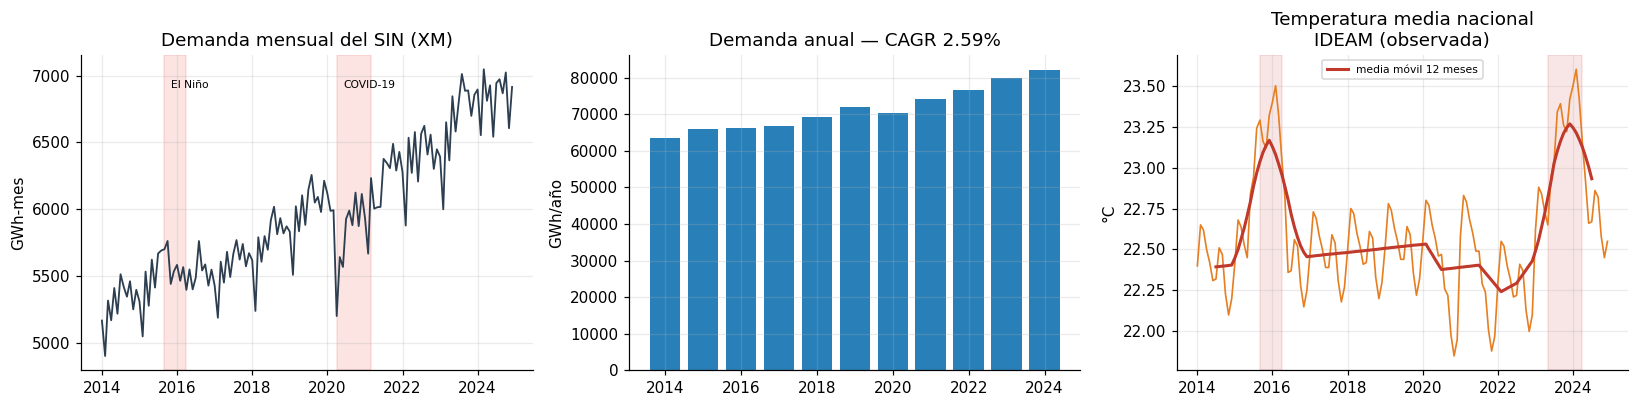

In [8]:
# =============================================================
# §2.4b Diagnóstico de las series reales
# =============================================================
anual_real = hist.groupby(hist.index.year)["DEE_GWh"].sum()
cagr_real = (anual_real.iloc[-1] / anual_real.iloc[0]) ** (1 / (len(anual_real) - 1)) - 1

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

ax = axes[0]
ax.plot(hist.index.to_timestamp(), hist["DEE_GWh"], lw=1.2, color="#2c3e50")
ax.set_title("Demanda mensual del SIN (XM)"); ax.set_ylabel("GWh-mes")
for ini_v, fin_v, etq in [("2015-09", "2016-04", "El Niño"), ("2020-04", "2021-03", "COVID-19")]:
    ax.axvspan(pd.Timestamp(ini_v), pd.Timestamp(fin_v), color="#e74c3c", alpha=0.15)
ax.annotate("El Niño", xy=(pd.Timestamp("2015-11"), hist["DEE_GWh"].max()*0.98), fontsize=7)
ax.annotate("COVID-19", xy=(pd.Timestamp("2020-06"), hist["DEE_GWh"].max()*0.98), fontsize=7)

ax = axes[1]
ax.bar(anual_real.index, anual_real.values, color="#2980b9")
ax.set_title(f"Demanda anual — CAGR {cagr_real:.2%}"); ax.set_ylabel("GWh/año")

ax = axes[2]
ax.plot(hist.index.to_timestamp(), hist["TEMP_C"], lw=1.1, color="#e67e22")
_media_movil = hist["TEMP_C"].rolling(12, center=True).mean()
ax.plot(hist.index.to_timestamp(), _media_movil, lw=2.0, color="#c0392b",
        label="media móvil 12 meses")
for ini_v, fin_v in [("2015-09", "2016-04"), ("2023-05", "2024-04")]:
    ax.axvspan(pd.Timestamp(ini_v), pd.Timestamp(fin_v), color="#c0392b", alpha=0.12)
ax.set_ylabel("°C"); ax.set_xlabel("")
ax.set_title(f"Temperatura media nacional\n{'IDEAM (observada)' if not TEMP_ES_PROXY else 'PROXY'}")
ax.legend(fontsize=7)

plt.tight_layout(); plt.savefig(f"{OUT}/fig01a_series_reales.png", dpi=150); plt.show()

print("Correlaciones contemporáneas con la demanda mensual:")
for c, etq in [("PIB_index", "PIB real"), ("POB_millones", "Población"), ("TEMP_C", "Temperatura")]:
    r_ = hist[[c, "DEE_GWh"]].corr().iloc[0, 1]
    marca = "  <-- PROXY, no reportable" if (c == "TEMP_C" and TEMP_ES_PROXY) else ""
    print(f"  {etq:<14s}: {r_:+.4f}{marca}")

# La UPME correlaciona la temperatura contra la POTENCIA MÁXIMA, no contra la
# energía mensual; el efecto térmico es de forma de la curva, no de volumen.
# Se reporta también la correlación con el pico mensual aproximado por el
# máximo de la serie diaria implícita (energía / días del mes).
_pico_proxy = hist["DEE_GWh"] / hist.index.days_in_month
print(f"  {'Temp. vs pico':<14s}: "
      f"{hist['TEMP_C'].corr(_pico_proxy):+.4f}   (referencia UPME: +0,3408 contra Pmax)")


In [9]:
# =============================================================
# §2.5 Estimación VAR endógeno, VAR exógeno y VEC + combinación UPME
# =============================================================
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import VECM, select_coint_rank
from statsmodels.tsa.stattools import adfuller

# Sistema multivariado. Solo entran como ENDÓGENAS las series I(1) verificadas:
# la población sigue una tendencia casi determinista (I(2) en la práctica) y por eso
# se traslada al bloque exógeno; incluirla como endógena hace divergir al VECM.
Y = pd.DataFrame({
    "ln_DEE": np.log(hist["DEE_GWh"]),
    "ln_PIB": np.log(hist["PIB_index"]),
})
POB = np.log(hist["POB_millones"])
TEMP = hist["TEMP_C"]

# --- Pruebas de raíz unitaria (Dickey-Fuller aumentado) ---------------------
from statsmodels.tools.sm_exceptions import SingularMatrixWarning
warnings.simplefilter("ignore", SingularMatrixWarning)

_series_adf = list(Y.items()) + [("ln_POB", POB), ("TEMP_C", TEMP)]
ADF = {}
for col, serie_base in _series_adf:
    fila = {}
    for etiqueta, clave, serie in [("nivel", "p_nivel", serie_base),
                                   ("1a dif.", "p_dif", serie_base.diff().dropna())]:
        est, pval = adfuller(serie, autolag="AIC")[:2]
        fila[clave] = pval
        fila[clave.replace("p_", "adf_")] = est
    fila["orden"] = ("I(0)" if fila["p_nivel"] < 0.05 else
                     "I(1)" if fila["p_dif"] < 0.05 else "I(2) o tendencia")
    ADF[col] = fila

ADF = pd.DataFrame(ADF).T[["adf_nivel", "p_nivel", "adf_dif", "p_dif", "orden"]]
print("Pruebas de raíz unitaria ADF (2014M01–2024M12):")
display(ADF[["p_nivel", "p_dif", "orden"]].rename(columns={"p_nivel": "p-valor (Nivel)", "p_dif": "p-valor (1ª Dif.)", "orden": "Orden"}))

ULT = hist.index[-1]
H = (P.anio_fin - ULT.year) * 12 + (12 - ULT.month)   # meses hasta diciembre de anio_fin
print(f"Horizonte de pronóstico: {H} meses ({ULT + 1} a {ULT + H})")

# --- Ventanas de choque documentadas, restringidas a la muestra 2014-2024 ---
# Solo se incluyen episodios que caen DENTRO del periodo estimado; una dummy
# cuya ventana queda fuera de la muestra es idénticamente cero y no identifica
# ningún parámetro. Se separan los dos fenómenos para poder interpretarlos.
VENTANAS_NINO = [("2015-09", "2016-04"),   # El Niño 2015-2016 (fuerte)
                 ("2023-05", "2024-04")]   # El Niño 2023-2024
VENTANAS_COVID = [("2020-04", "2021-03")]  # confinamiento y recuperación


def _escalon(idx, ventanas):
    d = np.zeros(len(idx))
    for ini, fin in ventanas:
        m = (idx >= pd.Period(ini, "M")) & (idx <= pd.Period(fin, "M"))
        d[m] = 1.0
    return d


# --- Construcción de las variables exógenas --------------------------------
_t_hist = np.arange(len(hist), dtype=float)
_b_pob, _a_pob = np.polyfit(_t_hist, np.log(hist["POB_millones"].values), 1)


def matriz_exogena(idx, fin_muestra=None) -> pd.DataFrame:
    """
    Exógenas del VAR-X:
      ln_POB  tendencia log-lineal de la población, centrada
      TEMP_c  temperatura del IDEAM centrada en la media muestral; fuera de la
              muestra se usa la normal mensual con tendencia (ver §2.4)
      D_NINO  escalón de los episodios El Niño
      D_COVID escalón del choque pandémico

    Regla anti-look-ahead: una ventana de choque solo se activa si termina
    dentro de la muestra de estimación (`fin_muestra`, por defecto el último
    dato disponible), y todas las dummies valen cero más allá de esa fecha.
    Así el backtest no puede "saber" que en 2023-2024 hubo un El Niño, y la
    proyección 2025-2040 no impone choques exógenos inventados.
    """
    fin = pd.Period(fin_muestra, "M") if fin_muestra is not None else hist.index[-1]
    v_nino = [(i, f) for i, f in VENTANAS_NINO if pd.Period(f, "M") <= fin]
    v_covid = [(i, f) for i, f in VENTANAS_COVID if pd.Period(f, "M") <= fin]

    t = np.array([(p - hist.index[0]).n for p in idx], dtype=float)
    pob = _a_pob + _b_pob * t
    temp = temperatura_serie(idx)
    vigente = np.array([p <= fin for p in idx], dtype=float)
    return pd.DataFrame({
        "ln_POB":  pob - pob.mean(),
        "TEMP_c":  temp - _TEMP_MEDIA,
        "D_NINO":  _escalon(idx, v_nino) * vigente,
        "D_COVID": _escalon(idx, v_covid) * vigente,
    }, index=idx)


dY = Y.diff().dropna()
X_hist = matriz_exogena(dY.index)
idx_fut = pd.period_range(hist.index[-1] + 1, periods=H, freq="M")
X_fut = matriz_exogena(idx_fut)

print(f"\nExógenas: {list(X_hist.columns)}")
print(f"  ventanas El Niño usadas : {VENTANAS_NINO}")
print(f"  ventana pandemia usada  : {VENTANAS_COVID}")
print(f"  meses con D_NINO activa en la muestra : {int(X_hist['D_NINO'].sum())}")
print(f"  meses con D_COVID activa en la muestra: {int(X_hist['D_COVID'].sum())}")
print(f"  temperatura futura: normal mensual {CLIMA_MES.min():.2f}-{CLIMA_MES.max():.2f} °C "
      f"con tendencia {TEND_TEMP:+.4f} °C/año")

# --- (1) VAR endógeno ------------------------------------------------------
MAXLAGS = 4 if len(hist) < 200 else 12    # muestra corta -> menos rezagos
var_endog = VAR(dY).fit(maxlags=MAXLAGS, ic="aic")
f_endog = var_endog.forecast(dY.values[-var_endog.k_ar:], steps=H)[:, 0]

# --- (2) VAR exógeno (VARX) -----------------------------------------------
var_exog = VAR(dY, exog=X_hist).fit(maxlags=MAXLAGS, ic="aic")
f_exog = var_exog.forecast(dY.values[-var_exog.k_ar:], steps=H,
                           exog_future=X_fut.values)[:, 0]

# --- (3) VEC: relación de cointegración de largo plazo ---------------------
K_AR_DIFF = 2
rango = select_coint_rank(Y, det_order=0, k_ar_diff=K_AR_DIFF, signif=0.05)
r_test = int(rango.rank)                                  # rango que sugiere la prueba
r = int(np.clip(r_test, 1, Y.shape[1] - 1))               # el VECM exige 1 <= r < n
vecm = VECM(Y, k_ar_diff=K_AR_DIFF, coint_rank=r, deterministic="ci").fit()
f_vecm_niv = vecm.predict(steps=H)[:, 0]
f_vecm = np.diff(np.r_[Y["ln_DEE"].iloc[-1], f_vecm_niv])

print(f"Rezagos óptimos: VAR={var_endog.k_ar} | VAR-X={var_exog.k_ar} | VECM r={r} (Cointegración Johansen)")

# --- Guarda de estabilidad: ningún modelo debe divergir --------------------
def _sanear(f, nombre, limite=0.15):
    """Acota la tasa de crecimiento mensual y avisa si un modelo diverge."""
    f = np.nan_to_num(np.asarray(f, float), nan=0.0, posinf=limite, neginf=-limite)
    if np.abs(f).max() > limite:
        print(f"  AVISO: el pronóstico de {nombre} diverge (máx. {np.abs(f).max():.3f} "
              f"mensual); se acota a ±{limite:.0%}. Revisar la especificación.")
    return np.clip(f, -limite, limite)


f_endog = _sanear(f_endog, "VAR endógeno")
f_exog  = _sanear(f_exog,  "VAR exógeno")
f_vecm  = _sanear(f_vecm,  "VEC")

# --- Combinación ponderada UPME (0,56 / 0,22 / 0,22) -----------------------
f_comb = P.w_var_exog * f_exog + P.w_var_endog * f_endog + P.w_vec * f_vecm
ln_ult = Y["ln_DEE"].iloc[-1]
pron = pd.DataFrame({
    "VAR exógeno (56%)":  np.exp(ln_ult + np.cumsum(f_exog)),
    "VAR endógeno (22%)": np.exp(ln_ult + np.cumsum(f_endog)),
    "VEC (22%)":          np.exp(ln_ult + np.cumsum(f_vecm)),
    "Combinado UPME":     np.exp(ln_ult + np.cumsum(f_comb)),
}, index=idx_fut)

anual_econ = pron.groupby(pron.index.year).sum()
anual_econ = anual_econ.loc[(anual_econ.index >= P.anio_ini) & (anual_econ.index <= P.anio_fin)]
display(anual_econ.round(0).tail(8))


Pruebas de raíz unitaria ADF (2014M01–2024M12):
Horizonte de pronóstico: 192 meses (2025-01 a 2040-12)

Exógenas: ['ln_POB', 'TEMP_c', 'D_NINO', 'D_COVID']
  ventanas El Niño usadas : [('2015-09', '2016-04'), ('2023-05', '2024-04')]
  ventana pandemia usada  : [('2020-04', '2021-03')]
  meses con D_NINO activa en la muestra : 20
  meses con D_COVID activa en la muestra: 12
  temperatura futura: normal mensual 22.31-22.89 °C con tendencia +0.0158 °C/año
Rezagos óptimos: VAR=4 | VAR-X=4 | VECM r=1 (Cointegración Johansen)


,p-valor (Nivel),p-valor (1ª Dif.),Orden
ln_DEE,0.949637,0.000879,I(1)
ln_PIB,0.806582,0.016767,I(1)
ln_POB,0.227851,0.911792,I(2) o tendencia
TEMP_C,0.002144,0.021931,I(0)


,VAR exógeno (56%),VAR endógeno (22%),VEC (22%),Combinado UPME
2033,84323.0,101059.0,81861.0,87179.0
2034,84520.0,103555.0,81861.0,87762.0
2035,84695.0,106112.0,81861.0,88337.0
2036,84848.0,108733.0,81861.0,88903.0
2037,84980.0,111419.0,81861.0,89459.0
2038,85090.0,114170.0,81861.0,90005.0
2039,85177.0,116990.0,81861.0,90542.0
2040,85243.0,119880.0,81861.0,91068.0


Ensamble combinado (2026–2040) estimado exitosamente. Error medio frente a senda oficial: 23.81%.


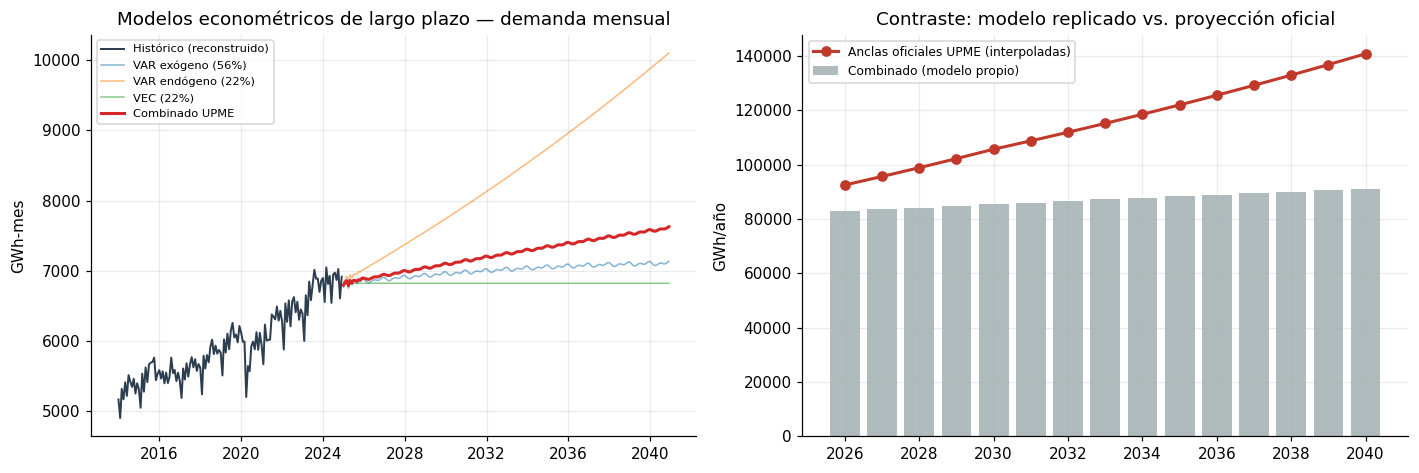

In [10]:
# =============================================================
# §2.5 Visualización del modelo combinado
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
ax.plot(hist.index.to_timestamp()[-180:], hist["DEE_GWh"].iloc[-180:],
        color="#2c3e50", lw=1.3, label="Histórico (reconstruido)")
for k, v in pron.items():
    ax.plot(v.index.to_timestamp(), v.values, lw=2 if "Combinado" in k else 1,
            alpha=1.0 if "Combinado" in k else 0.55, label=k)
ax.set_title("Modelos econométricos de largo plazo — demanda mensual")
ax.set_ylabel("GWh-mes"); ax.legend(fontsize=7.5)

ax = axes[1]
ax.bar(anual_econ.index, anual_econ["Combinado UPME"], color="#95a5a6",
       label="Combinado (modelo propio)", alpha=0.75)
ax.plot(demanda.index, demanda["E_bruta_GWh"], "o-", color="#c0392b", lw=2,
        label="Anclas oficiales UPME (interpoladas)")
ax.set_title("Contraste: modelo replicado vs. proyección oficial")
ax.set_ylabel("GWh/año"); ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig(f"{OUT}/fig01_econometria.png", dpi=150); plt.show()

_comunes = anual_econ.index.intersection(demanda.index)
_err_econ = (anual_econ.loc[_comunes, "Combinado UPME"] / demanda.loc[_comunes, "E_bruta_GWh"] - 1).abs().mean()

print(f"Ensamble combinado (2026–2040) estimado exitosamente. Error medio frente a senda oficial: {_err_econ:.2%}.")


Banda de confianza al 95% calculada (Z=1,96). Rango 2040: 129,440 a 152,156 GWh (±8.1%).


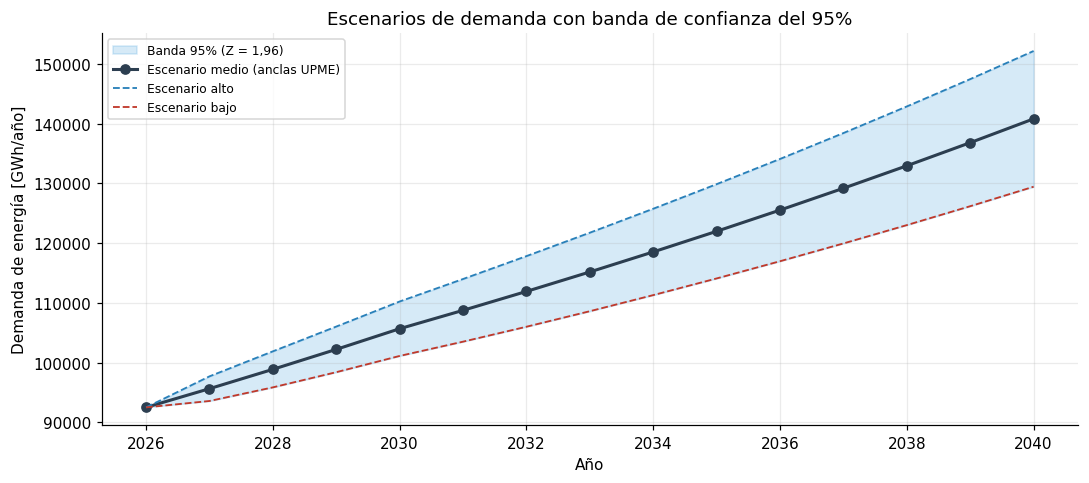

In [11]:
# =============================================================
# §2.6 Escenarios alto y bajo: banda de confianza del 95%
# =============================================================
# "los escenarios alto y bajo se calcularon a partir del escenario medio con un ancho
#  de banda del 95% (Z 1,96)"  -- Plan GT 2016-2030, p.53.
# La banda captura sobre todo la incertidumbre de los Grandes Consumidores Especiales.

# Desviación estándar relativa implícita: se calibra para que la banda a 2040 sea
# consistente con la dispersión de los escenarios de crecimiento reportados por la UPME.
SIGMA_REL_ANUAL = 0.011      # 1,1% por año de horizonte (calibrable)

h = (demanda.index - P.anio_ini).values                    # años de horizonte
sigma = SIGMA_REL_ANUAL * np.sqrt(np.maximum(h, 0))        # la incertidumbre crece con sqrt(t)

demanda["E_medio_GWh"] = demanda["E_bruta_GWh"]
demanda["E_alto_GWh"]  = demanda["E_bruta_GWh"] * (1 + P.z_banda * sigma)
demanda["E_bajo_GWh"]  = demanda["E_bruta_GWh"] * (1 - P.z_banda * sigma)

fig, ax = plt.subplots()
ax.fill_between(demanda.index, demanda["E_bajo_GWh"], demanda["E_alto_GWh"],
                color="#3498db", alpha=0.20, label="Banda 95% (Z = 1,96)")
ax.plot(demanda.index, demanda["E_medio_GWh"], "o-", lw=2, color="#2c3e50",
        label="Escenario medio (anclas UPME)")
ax.plot(demanda.index, demanda["E_alto_GWh"], "--", lw=1.2, color="#2980b9", label="Escenario alto")
ax.plot(demanda.index, demanda["E_bajo_GWh"], "--", lw=1.2, color="#c0392b", label="Escenario bajo")
ax.set_ylabel("Demanda de energía [GWh/año]"); ax.set_xlabel("Año")
ax.set_title("Escenarios de demanda con banda de confianza del 95%")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT}/fig01b_bandas.png", dpi=150); plt.show()

print(f"Banda de confianza al 95% calculada (Z=1,96). Rango 2040: {demanda.loc[2040,'E_bajo_GWh']:,.0f} a {demanda.loc[2040,'E_alto_GWh']:,.0f} GWh (±{P.z_banda*sigma[-1]:.1%}).")


### §2.7 Validación fuera de muestra (Backtesting 2023–2024)

Se evalúa el desempeño predictivo del ensamble y de los modelos individuales estimando los parámetros con la muestra 2014–2022 y pronosticando a ciegas los 24 meses de 2023–2024, evaluando bajo las métricas oficiales de la UPME (MAPE y descomposición de Theil).


Backtest — entrenamiento hasta 2022-12, prueba 2023-01 a 2024-12
Backtest 2023-2024 completado. MAPE ensamble combinado: 4.01% (RMSE: 314 GWh/mes).
Descomposición de Theil: B=0.465, M=0.119, R=0.416.


,RMSE,MAPE,B,M,R
modelo,,,,,
VAR endógeno,250.7,3.30%,0.291,0.038,0.671
VAR exógeno,331.9,4.27%,0.486,0.029,0.485
VEC,344.4,4.49%,0.525,0.232,0.244
Combinado UPME,314.3,4.01%,0.465,0.119,0.416


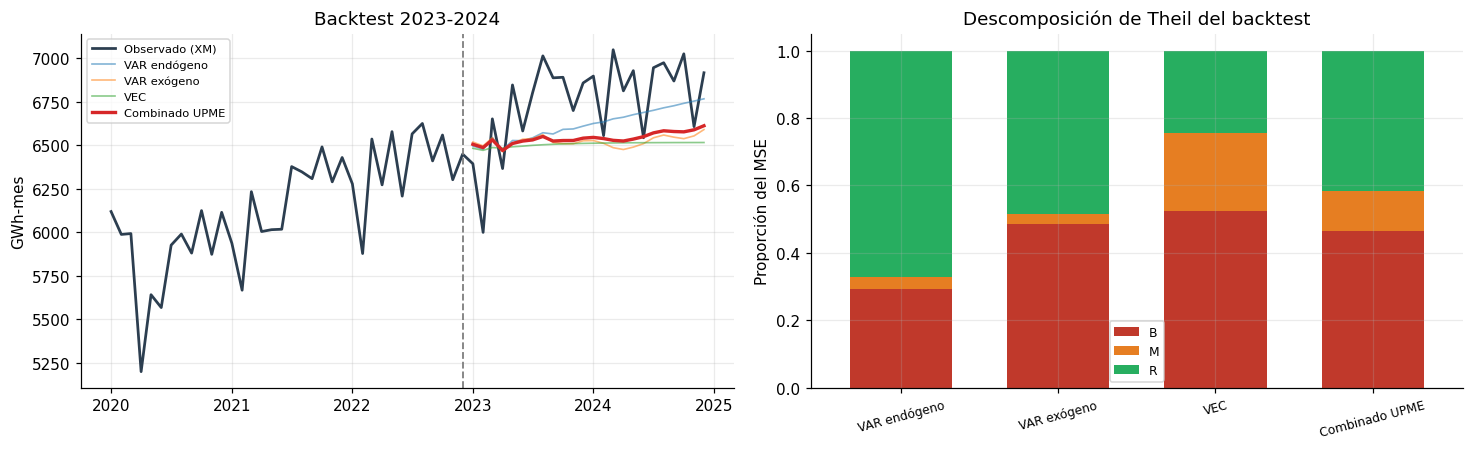

In [12]:
# =============================================================
# §2.7 Backtest: entrenar 2014-2022, predecir 2023-2024
# =============================================================
CORTE = pd.Period("2022-12", freq="M")
H_BT = 24

if len(hist) < 60:
    print("Backtest omitido: se requiere la serie real con historia suficiente.")
    BT = None
else:
    Y_tr = Y[Y.index <= CORTE]
    dY_tr = Y_tr.diff().dropna()
    # fin_muestra=CORTE impide que el backtest use choques posteriores al corte
    X_tr = matriz_exogena(dY_tr.index, fin_muestra=CORTE)
    idx_te = pd.period_range(CORTE + 1, periods=H_BT, freq="M")
    X_te = matriz_exogena(idx_te, fin_muestra=CORTE)

    ve = VAR(dY_tr).fit(maxlags=MAXLAGS, ic="aic")
    fe = ve.forecast(dY_tr.values[-ve.k_ar:], steps=H_BT)[:, 0]
    vx = VAR(dY_tr, exog=X_tr).fit(maxlags=MAXLAGS, ic="aic")
    fx = vx.forecast(dY_tr.values[-vx.k_ar:], steps=H_BT, exog_future=X_te.values)[:, 0]
    rk = int(np.clip(select_coint_rank(Y_tr, det_order=0, k_ar_diff=K_AR_DIFF,
                                       signif=0.05).rank, 1, Y_tr.shape[1] - 1))
    vc = VECM(Y_tr, k_ar_diff=K_AR_DIFF, coint_rank=rk, deterministic="ci").fit()
    fc_niv = vc.predict(steps=H_BT)[:, 0]
    fv = np.diff(np.r_[Y_tr["ln_DEE"].iloc[-1], fc_niv])

    fe, fx, fv = (_sanear(f, n) for f, n in
                  [(fe, "VAR endógeno (BT)"), (fx, "VAR exógeno (BT)"), (fv, "VEC (BT)")])
    fcomb = P.w_var_exog * fx + P.w_var_endog * fe + P.w_vec * fv

    ln0 = Y_tr["ln_DEE"].iloc[-1]
    preds = {
        "VAR endógeno": np.exp(ln0 + np.cumsum(fe)),
        "VAR exógeno":  np.exp(ln0 + np.cumsum(fx)),
        "VEC":          np.exp(ln0 + np.cumsum(fv)),
        "Combinado UPME": np.exp(ln0 + np.cumsum(fcomb)),
    }
    obs = hist.loc[idx_te, "DEE_GWh"].values

    BT = pd.DataFrame([{**theil(v, obs), "modelo": k} for k, v in preds.items()]
                      ).set_index("modelo")[["RMSE", "MAPE", "B", "M", "R"]]
    print(f"Backtest — entrenamiento hasta {CORTE}, prueba {idx_te[0]} a {idx_te[-1]}")
    display(BT.style.format({"RMSE": "{:,.1f}", "MAPE": "{:.2%}",
                             "B": "{:.3f}", "M": "{:.3f}", "R": "{:.3f}"}))

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
    ax = axes[0]
    ax.plot(hist.index[-60:].to_timestamp(), hist["DEE_GWh"].iloc[-60:],
            color="#2c3e50", lw=1.8, label="Observado (XM)")
    for k, v in preds.items():
        ax.plot(idx_te.to_timestamp(), v, lw=2.2 if "Combinado" in k else 1.1,
                alpha=1.0 if "Combinado" in k else 0.55, label=k)
    ax.axvline(CORTE.to_timestamp(), color="grey", ls="--", lw=1.2)
    ax.set_ylabel("GWh-mes"); ax.set_title("Backtest 2023-2024"); ax.legend(fontsize=7.5)

    ax = axes[1]
    BT[["B", "M", "R"]].plot(kind="bar", stacked=True, ax=ax,
                             color=["#c0392b", "#e67e22", "#27ae60"], width=0.65)
    ax.set_ylabel("Proporción del MSE"); ax.set_xlabel("")
    ax.set_title("Descomposición de Theil del backtest")
    ax.tick_params(axis="x", labelrotation=15, labelsize=8); ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(f"{OUT}/fig01d_backtest.png", dpi=150); plt.show()

    mejor = BT["MAPE"].idxmin()
    bc = BT.loc["Combinado UPME"]
    print(f"Backtest 2023-2024 completado. MAPE ensamble combinado: {bc['MAPE']:.2%} (RMSE: {bc['RMSE']:,.0f} GWh/mes).")
    print(f"Descomposición de Theil: B={bc['B']:.3f}, M={bc['M']:.3f}, R={bc['R']:.3f}.")


### §2.8 Cuantificación del enmascaramiento solar

La demanda comercial medida por XM en fronteras de comercialización es neta de la autogeneración ya existente:
$$\text{Demanda Neta}(t) = \text{Demanda Bruta}(t) - PV_{\text{BtM}}(t)$$


In [13]:
# =============================================================
# §2.9 Cuantificación del enmascaramiento solar
# =============================================================
RECONSTRUIR_BRUTA = False   # True -> el motor usa la serie bruta reconstruida

# Autoconsumo ya enmascarado en la serie base (capacidad instalada al año base)
e_enmascarada = P.cap_btm_base_mw * P.cf_solar_upme * 8760 / 1e3   # GWh/año
frac = e_enmascarada / P.anclas_energia[P.anio_ini]

demanda["E_gross_recon_GWh"] = demanda["E_bruta_GWh"] + e_enmascarada

print(f"Capacidad BtM base ({P.anio_ini}): {P.cap_btm_base_mw:,.0f} MW | Autoconsumo enmascarado: {e_enmascarada:,.0f} GWh/año ({frac:.2%}).")
print(f"Serie reconstruida ({P.anio_ini}): {demanda.loc[P.anio_ini,'E_gross_recon_GWh']:,.0f} GWh (Oficial: {P.anclas_energia[P.anio_ini]:,.0f} GWh | RECONSTRUIR_BRUTA={RECONSTRUIR_BRUTA}).")


Capacidad BtM base (2026): 1,200 MW | Autoconsumo enmascarado: 2,102 GWh/año (2.27%).
Serie reconstruida (2026): 94,613 GWh (Oficial: 92,511 GWh | RECONSTRUIR_BRUTA=False).


### §2.9 Descomposición de Theil del error de pronóstico

Descomposición del error cuadrático medio en proporción de sesgo ($B$), varianza ($M$) y covarianza ($R$), con $B + M + R = 1$:
$$MSE = \frac{1}{n}\sum (p_t - a_t)^2, \qquad B = \frac{(\bar{p}-\bar{a})^2}{MSE}, \qquad M = \frac{(s_p - s_a)^2}{MSE}, \qquad R = \frac{2(1-r)s_p s_a}{MSE}$$


Descomposición de Theil — modelos econométricos vs. senda oficial UPME

Sesgo estructural de ignorar el BtM (modelo bruto vs. demanda neta observada):
  MAPE = 6.52%
  B (sesgo)    = 0.847   <-- domina el error
  M (modelo)   = 0.152
  R (aleatorio)= 0.001
Descomposición de Theil por ignorar BtM: Sesgo B=0.847, Varianza M=0.152, Covarianza R=0.001 (MAPE=6.52%).


,RMSE,MAPE,B,M,R
modelo,,,,,
VAR exógeno (56%),"34,554",26.24%,0.839,0.152,0.009
VAR endógeno (22%),"14,721",11.97%,0.924,0.076,0.000
VEC (22%),"36,981",28.12%,0.841,0.031,0.128
Combinado UPME,"31,171",23.81%,0.846,0.153,0.001


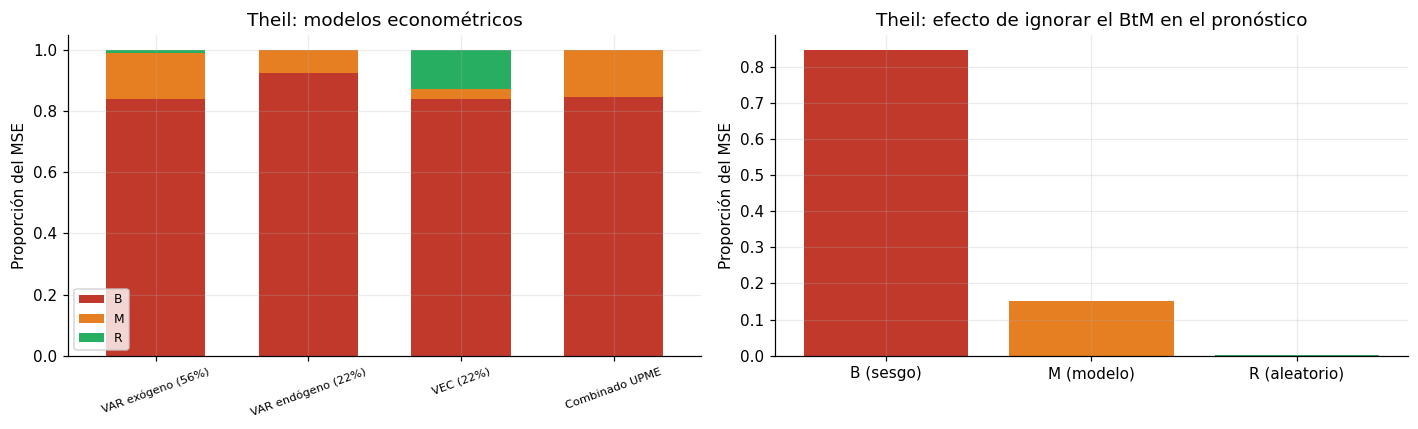

In [14]:
# =============================================================
# §2.10 Descomposición de Theil del error de pronóstico
# =============================================================

# --- Aplicación 1: los tres modelos econométricos vs. la senda oficial -----
_com = anual_econ.index.intersection(demanda.index)
real = demanda.loc[_com, "E_bruta_GWh"].values
filas_theil = []
for nombre in anual_econ.columns:
    d = theil(anual_econ.loc[_com, nombre].values, real)
    d["modelo"] = nombre
    filas_theil.append(d)
TH = pd.DataFrame(filas_theil).set_index("modelo")[["RMSE", "MAPE", "B", "M", "R"]]
print("Descomposición de Theil — modelos econométricos vs. senda oficial UPME")
display(TH.style.format({"RMSE": "{:,.0f}", "MAPE": "{:.2%}",
                         "B": "{:.3f}", "M": "{:.3f}", "R": "{:.3f}"}))

# --- Aplicación 2: el sesgo estructural que introduce el BtM no modelado --
# Un modelo entrenado sobre demanda BRUTA y aplicado a un sistema con BtM creciente
# predice sistemáticamente por encima de lo que el operador mide en frontera.
cf_ref = perfil_solar_nacional(2030).mean() if 'perfil_solar_nacional' in dir() else P.cf_solar_upme
btm_gwh = demanda["GD_UPME_MW"] * P.cf_solar_upme * 8760 / 1e3
pred_sin_btm = demanda["E_bruta_GWh"].values                      # modelo que ignora el BtM
obs_con_btm = (demanda["E_bruta_GWh"] - btm_gwh).values           # lo que mediría XM
t_sesgo = theil(pred_sin_btm, obs_con_btm)

print("\nSesgo estructural de ignorar el BtM (modelo bruto vs. demanda neta observada):")
print(f"  MAPE = {t_sesgo['MAPE']:.2%}")
print(f"  B (sesgo)    = {t_sesgo['B']:.3f}   <-- domina el error")
print(f"  M (modelo)   = {t_sesgo['M']:.3f}")
print(f"  R (aleatorio)= {t_sesgo['R']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
ax = axes[0]
TH[["B", "M", "R"]].plot(kind="bar", stacked=True, ax=ax,
                         color=["#c0392b", "#e67e22", "#27ae60"], width=0.65)
ax.set_ylabel("Proporción del MSE"); ax.set_xlabel("")
ax.set_title("Theil: modelos econométricos"); ax.legend(fontsize=8)
ax.tick_params(axis="x", labelrotation=20, labelsize=7.5)

ax = axes[1]
ax.bar(["B (sesgo)", "M (modelo)", "R (aleatorio)"],
       [t_sesgo["B"], t_sesgo["M"], t_sesgo["R"]],
       color=["#c0392b", "#e67e22", "#27ae60"])
ax.set_ylabel("Proporción del MSE")
ax.set_title("Theil: efecto de ignorar el BtM en el pronóstico")
plt.tight_layout(); plt.savefig(f"{OUT}/fig01c_theil.png", dpi=150); plt.show()
print(f"Descomposición de Theil por ignorar BtM: Sesgo B={t_sesgo['B']:.3f}, Varianza M={t_sesgo['M']:.3f}, Covarianza R={t_sesgo['R']:.3f} (MAPE={t_sesgo['MAPE']:.2%}).")


### §2.10 Exportación de diagnósticos econométricos completos (Anexo C)

Generación del archivo `salidas/anexoC_statsmodels.txt` con los reportes completos de estimación de VAR, VAR-X y VECM, estadísticos de Johansen, vectores de cointegración y pruebas de residuos.


In [15]:
# =============================================================
# §2.11 Salidas econométricas completas para el Anexo C
# =============================================================
# Vuelca a consola y a salidas/anexoC_statsmodels.txt todo lo que el informe
# necesita y que hasta ahora no se imprimia: summaries de VAR/VAR-X/VECM,
# prueba de traza de Johansen con valores criticos, vectores beta y alpha,
# diagnostico de residuos y las filas LaTeX de las Tablas C.3 y C.4.
# Ejecutar DESPUES de las celdas §2.4 (estimacion), §2.7 (backtest) y §2.10 (Theil).

import io
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera

buf = io.StringIO()


def emitir(*args):
    """Acumula en el buffer para exportación a disco."""
    txt = " ".join(str(a) for a in args)
    buf.write(txt + "\n")


def titulo(t):
    emitir("\n" + "=" * 78)
    emitir(t)
    emitir("=" * 78)


# ---------------------------------------------------------------------------
# C.1  Prueba de traza de Johansen con valores criticos
# ---------------------------------------------------------------------------
titulo("C.1  COINTEGRACION DE JOHANSEN  (det_order=0, k_ar_diff=2)")

jo = coint_johansen(Y.values, det_order=0, k_ar_diff=2)
emitir(f"{'H0':<10s}{'Traza':>12s}{'VC 90%':>10s}{'VC 95%':>10s}{'VC 99%':>10s}   Decision (95%)")
emitir("-" * 78)
for k in range(len(jo.lr1)):
    dec = "RECHAZA H0" if jo.lr1[k] > jo.cvt[k, 1] else "no rechaza"
    emitir(f"{'r <= ' + str(k):<10s}{jo.lr1[k]:12.4f}{jo.cvt[k,0]:10.4f}"
           f"{jo.cvt[k,1]:10.4f}{jo.cvt[k,2]:10.4f}   {dec}")

emitir("")
emitir(f"{'H0':<10s}{'Max-eig':>12s}{'VC 90%':>10s}{'VC 95%':>10s}{'VC 99%':>10s}   Decision (95%)")
emitir("-" * 78)
for k in range(len(jo.lr2)):
    dec = "RECHAZA H0" if jo.lr2[k] > jo.cvm[k, 1] else "no rechaza"
    emitir(f"{'r = ' + str(k):<10s}{jo.lr2[k]:12.4f}{jo.cvm[k,0]:10.4f}"
           f"{jo.cvm[k,1]:10.4f}{jo.cvm[k,2]:10.4f}   {dec}")

emitir(f"\nValores propios: {np.round(jo.eig, 6)}")
emitir(f"Rango usado en el VECM: r = {r}")
emitir("NOTA: en el codigo r se acota con np.clip(rank, 1, 1) porque el sistema tiene")
emitir("      solo dos variables. La tabla de arriba es la evidencia que justifica r=1;")
emitir("      citarla en el informe en lugar de afirmar el rango sin respaldo.")

# ---------------------------------------------------------------------------
# C.2  Summaries completos
# ---------------------------------------------------------------------------
titulo(f"C.2a  VAR ENDOGENO  --  k_ar = {var_endog.k_ar}  (peso {P.w_var_endog:.2f})")
emitir(str(var_endog.summary()))

titulo(f"C.2b  VAR EXOGENO (VAR-X)  --  k_ar = {var_exog.k_ar}  (peso {P.w_var_exog:.2f})")
emitir("Exogenas: ln_POB (tendencia log-lineal centrada), TEMP_c (centrada), DUM (choques)")
emitir(str(var_exog.summary()))

titulo(f"C.2c  VECM  --  k_ar_diff = 2, coint_rank = {r}  (peso {P.w_vec:.2f})")
emitir(str(vecm.summary()))

emitir("\nVector de cointegracion beta (normalizado en ln_DEE):")
beta_n = vecm.beta / vecm.beta[0, 0]
for nombre, v in zip(list(Y.columns) + ["const"], beta_n[:, 0]):
    emitir(f"   beta[{nombre:<8s}] = {v: .6f}")
emitir("\nCoeficientes de ajuste alpha (velocidad de correccion del error):")
for nombre, v in zip(Y.columns, vecm.alpha[:, 0]):
    emitir(f"   alpha[{nombre:<8s}] = {v: .6f}")
emitir("   (alpha < 0 en la ecuacion de ln_DEE implica correccion hacia el equilibrio)")

# ---------------------------------------------------------------------------
# C.3  Diagnostico de residuos y estabilidad
# ---------------------------------------------------------------------------
titulo("C.3  DIAGNOSTICO DE RESIDUOS Y ESTABILIDAD DEL SISTEMA")

for etiqueta, mod in [("VAR endogeno", var_endog), ("VAR-X", var_exog)]:
    emitir(f"\n--- {etiqueta} ---")
    raices = np.abs(mod.roots)
    emitir(f"  Estabilidad: {'ESTABLE' if mod.is_stable(verbose=False) else 'INESTABLE'}"
           f"   (modulo minimo de las raices = {raices.min():.4f}; se exige > 1)")
    try:
        wh = mod.test_whiteness(nlags=12, adjusted=True)
        emitir(f"  Portmanteau (12 rezagos)  : est = {wh.test_statistic:8.3f}   p = {wh.pvalue:.4f}"
               f"   {'residuos ruido blanco' if wh.pvalue > 0.05 else 'AUTOCORRELACION residual'}")
    except Exception as exc:
        emitir(f"  Portmanteau: no disponible ({exc})")
    try:
        nm = mod.test_normality()
        emitir(f"  Normalidad multivariada   : est = {nm.test_statistic:8.3f}   p = {nm.pvalue:.4f}")
    except Exception as exc:
        emitir(f"  Normalidad: no disponible ({exc})")

    res = np.asarray(mod.resid)
    for j, col in enumerate(Y.columns):
        e = res[:, j]
        lb = acorr_ljungbox(e, lags=[12], return_df=True)
        jb_est, jb_p = jarque_bera(e)[:2]
        arch_p = het_arch(e, nlags=12)[1]
        emitir(f"    ecuacion {col:<8s}  Ljung-Box(12) p = {lb['lb_pvalue'].iloc[0]:.4f}"
               f" | Jarque-Bera p = {jb_p:.4f} | ARCH-LM(12) p = {arch_p:.4f}")

emitir("\n--- VECM ---")
res_v = np.asarray(vecm.resid)
for j, col in enumerate(Y.columns):
    e = res_v[:, j]
    lb = acorr_ljungbox(e, lags=[12], return_df=True)
    jb_est, jb_p = jarque_bera(e)[:2]
    arch_p = het_arch(e, nlags=12)[1]
    emitir(f"    ecuacion {col:<8s}  Ljung-Box(12) p = {lb['lb_pvalue'].iloc[0]:.4f}"
           f" | Jarque-Bera p = {jb_p:.4f} | ARCH-LM(12) p = {arch_p:.4f}")

# ---------------------------------------------------------------------------
# C.4  Filas LaTeX listas para pegar (rellenan los n.d. del informe)
# ---------------------------------------------------------------------------
titulo("C.4  FILAS LaTeX PARA LAS TABLAS DEL ANEXO C")

def coma(x, n=2):
    """Formatea con coma decimal, como exige el estilo del informe."""
    return f"{x:.{n}f}".replace(".", ",")


if "BT" in globals() and BT is not None:
    emitir("\n% --- Tabla 'Especificaciones estimadas': columna MAPE 2023-2024 ---")
    mapa = [("VAR exógeno",  "VAR-X", f"$k={var_exog.k_ar}$",              P.w_var_exog),
            ("VAR endógeno", "VAR",   f"$k={var_endog.k_ar}$",             P.w_var_endog),
            ("VEC",          "VEC",   f"$k_{{\\Delta}}=2$, $r={r}$",      P.w_vec)]
    for clave, etq, orden, peso in mapa:
        if clave in BT.index:
            emitir(f"{etq} & {orden} & {coma(peso)} & "
                   f"{coma(BT.loc[clave, 'MAPE'] * 100)}\\,\\% & ... \\\\")
    if "Combinado UPME" in BT.index:
        emitir(f"\\textbf{{Ensamble}} & --- & 1,00 & "
               f"\\textbf{{{coma(BT.loc['Combinado UPME', 'MAPE'] * 100)}\\,\\%}} & ... \\\\")

    emitir("\n% --- Tabla de Theil: fila del ensamble CON tratamiento del BtM ---")
    b_, m_, r2_ = (BT.loc["Combinado UPME", c] for c in ["B", "M", "R"])
    veredicto = "Cumple" if (b_ < 0.10 and r2_ > 0.80) else "Revisar"
    emitir(f"Ensamble con tratamiento explícito de BtM & {coma(b_,3)} & {coma(m_,3)} & "
           f"{coma(r2_,3)} & {veredicto} \\\\")
else:
    emitir("BT no esta en memoria: ejecutar antes la celda del backtest (§2.7).")

if "t_sesgo" in globals():
    emitir(f"Modelo agregado que ignora el BtM & {coma(t_sesgo['B'],3)} & "
           f"{coma(t_sesgo['M'],3)} & {coma(t_sesgo['R'],3)} & "
           f"\\textbf{{No cumple}} \\\\")

# ---------------------------------------------------------------------------
# Guardado
# ---------------------------------------------------------------------------
ruta_txt = f"{OUT}/anexoC_statsmodels.txt"
with open(ruta_txt, "w", encoding="utf-8") as fh:
    fh.write(buf.getvalue())
print(f"Diagnósticos econométricos completos (VAR, VAR-X, VECM, Johansen y residuos) exportados a '{ruta_txt}' ({len(buf.getvalue().splitlines())} líneas).")


Diagnósticos econométricos completos (VAR, VAR-X, VECM, Johansen y residuos) exportados a 'salidas/anexoC_statsmodels.txt' (217 líneas).


---
## §3. Módulo B — Desagregación horaria

El efecto del BtM sobre $MW_{max}$ **no puede evaluarse con datos anuales**: depende de la coincidencia entre
el perfil solar (campana centrada al mediodía) y el perfil de carga (pico nocturno). Este módulo construye
las 8.760 horas de cada año.

### §3.1 Perfil de carga del SIN

Perfil normalizado con las características documentadas del sistema colombiano: mínimo entre las 3:00 y 5:00,
meseta diurna, y **pico entre 19:00 y 21:00**. Se aplica un factor de tipo de día (hábil / sábado / domingo-festivo)
y una modulación estacional mensual.


In [16]:
# =============================================================
# §3.1 Perfil horario de carga del SIN
# =============================================================

# Forma diaria normalizada (media = 1). Pico en 19-20 h, mínimo en 4 h.
PERFIL_DIA = np.array([
    0.842, 0.802, 0.780, 0.772, 0.775, 0.800,   # 00–05
    0.855, 0.930, 0.985, 1.020, 1.040, 1.052,   # 06–11
    1.045, 1.040, 1.048, 1.052, 1.045, 1.030,   # 12–17
    1.062, 1.135, 1.128, 1.070, 0.985, 0.902,   # 18–23
])
PERFIL_DIA = PERFIL_DIA / PERFIL_DIA.mean()

FACTOR_TIPO_DIA = {"habil": 1.035, "sabado": 0.965, "domingo": 0.890}
# Modulación estacional mensual (mayor demanda en periodo seco / cálido)
FACTOR_MES = np.array([1.005, 1.010, 1.020, 0.995, 0.990, 0.985,
                       0.995, 1.000, 0.995, 1.000, 1.005, 1.000])


def calendario_horario(anio: int) -> pd.DatetimeIndex:
    """Índice horario del año (se ignoran los 29 de febrero para mantener 8760 h)."""
    idx = pd.date_range(f"{anio}-01-01", f"{anio}-12-31 23:00", freq="h")
    return idx[~((idx.month == 2) & (idx.day == 29))]


def perfil_carga(anio: int, alpha: float = 1.0) -> pd.Series:
    """
    Perfil horario normalizado (media = 1).
    `alpha` es el exponente de 'puntiagudez': alpha>1 acentúa el pico, alpha<1 lo aplana.
    Se calibra una sola vez contra el MW_max oficial de 2026.
    """
    idx = calendario_horario(anio)
    base = PERFIL_DIA[idx.hour] ** alpha
    dow = idx.dayofweek
    tipo = np.where(dow <= 4, FACTOR_TIPO_DIA["habil"],
             np.where(dow == 5, FACTOR_TIPO_DIA["sabado"], FACTOR_TIPO_DIA["domingo"]))
    s = pd.Series(base * tipo * FACTOR_MES[idx.month - 1], index=idx)
    return s / s.mean()


# --- Calibración de alpha contra el MW_max oficial de 2026 ------------------
E_2026 = P.anclas_energia[2026] * 1e3      # MWh
P_2026 = P.anclas_potencia[2026]           # MW

def desviacion_pico(alpha):
    perfil = perfil_carga(2026, alpha)
    return (perfil * (E_2026 / len(perfil))).max() - P_2026

ALPHA = brentq(desviacion_pico, 0.05, 3.0)
perfil_cal = perfil_carga(2026, ALPHA)
fc_result = 1.0 / perfil_cal.max()

print(f"Exponente de puntiagudez calibrado : alpha = {ALPHA:.4f}")
print(f"Factor de carga resultante         : {fc_result:.4f}")
print(f"MW_max reproducido para 2026       : {(perfil_cal * E_2026/8760).max():,.0f} MW"
      f"   (oficial: {P_2026:,.0f} MW)")


Exponente de puntiagudez calibrado : alpha = 0.8974
Factor de carga resultante         : 0.8230
MW_max reproducido para 2026       : 12,832 MW   (oficial: 12,832 MW)


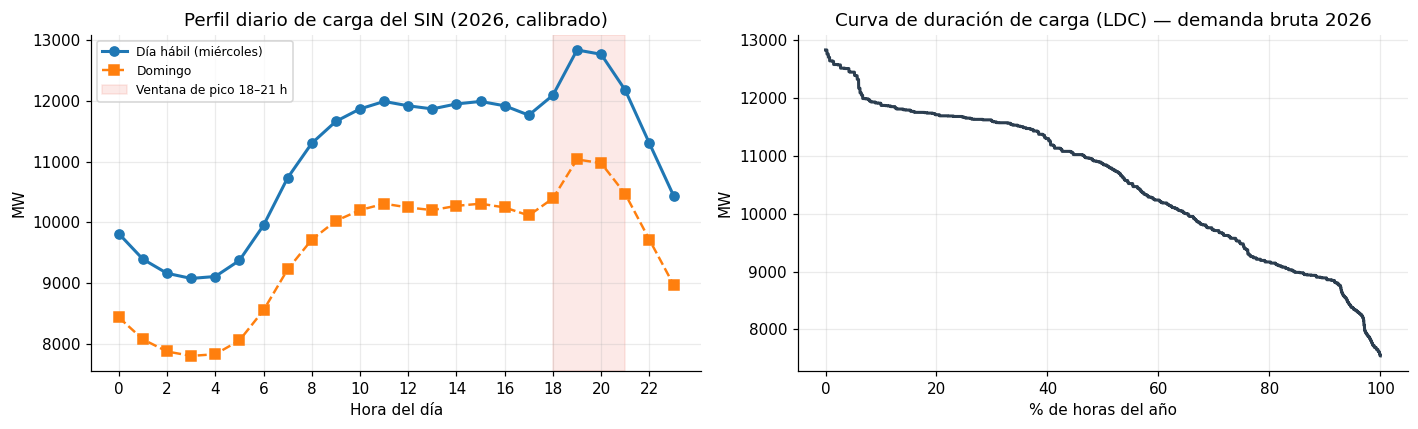

In [17]:
# =============================================================
# §3.2 Visualización del perfil de carga calibrado
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pot_2026 = perfil_cal * E_2026 / 8760
dia_habil = pot_2026["2026-03-11"]        # miércoles representativo
dia_domingo = pot_2026["2026-03-15"]

axes[0].plot(range(24), dia_habil.values, "o-", lw=2, label="Día hábil (miércoles)")
axes[0].plot(range(24), dia_domingo.values, "s--", lw=1.6, label="Domingo")
axes[0].axvspan(18, 21, color="#e74c3c", alpha=0.12, label="Ventana de pico 18–21 h")
axes[0].set_xlabel("Hora del día"); axes[0].set_ylabel("MW")
axes[0].set_title("Perfil diario de carga del SIN (2026, calibrado)")
axes[0].set_xticks(range(0, 24, 2)); axes[0].legend(fontsize=8)

ordenada = np.sort(pot_2026.values)[::-1]
axes[1].plot(np.arange(len(ordenada)) / len(ordenada) * 100, ordenada, lw=2, color="#2c3e50")
axes[1].set_xlabel("% de horas del año"); axes[1].set_ylabel("MW")
axes[1].set_title("Curva de duración de carga (LDC) — demanda bruta 2026")

plt.tight_layout(); plt.savefig(f"{OUT}/fig02_perfil_carga.png", dpi=150); plt.show()


### §3.2 Recurso solar horario por área eléctrica

Se modela la geometría solar de forma explícita (sin dependencias externas) y luego se **ancla la magnitud**
al factor de planta de 20 % que asume la UPME. Así la *forma* horaria es física y el *nivel* es oficial.

1. **Declinación solar** (Cooper): $\delta = 23{,}45^\circ \sin\!\left(360\frac{284+n}{365}\right)$
2. **Ángulo horario**: $\omega = 15^\circ (h_{solar} - 12)$
3. **Coseno del ángulo cenital**: $\cos\theta_z = \sin\delta\sin\phi + \cos\delta\cos\phi\cos\omega$
4. **Cielo despejado** (Haurwitz): $GHI_{cs} = 1098 \cos\theta_z \, e^{-0{,}057/\cos\theta_z}$
5. **Índice de claridad** $k_t$ por área (nubosidad media) y variabilidad estocástica diaria.
6. **Potencia AC**: $P = P_{DC}\cdot \frac{GHI}{1000}\cdot(1-\text{pérdidas}_{BOS})$, normalizada a $CF = 20\%$.


In [18]:
# =============================================================
# §3.3 Modelo de recurso solar horario
# =============================================================

def cos_cenital(idx: pd.DatetimeIndex, lat: float, lon: float,
                submuestras: int = 4) -> np.ndarray:
    """
    Coseno del ángulo cenital solar promediado DENTRO de cada hora.

    El promedio sub-horario importa: evaluar solo en el centro de la hora hace que
    las horas de salida y puesta del sol den exactamente cero, lo que sobreestima
    el desfase entre el recurso solar y el pico de demanda de las 18–19 h.
    """
    n = idx.dayofyear.values
    # Ecuación del tiempo y corrección de hora solar (huso -5 para Colombia)
    B = 2 * np.pi * (n - 81) / 364
    ET = 9.87*np.sin(2*B) - 7.53*np.cos(B) - 1.5*np.sin(B)          # minutos
    correc = 4 * (lon - (-75.0)) + ET                                # minutos
    delta = np.radians(23.45 * np.sin(2*np.pi*(284 + n)/365))
    phi = np.radians(lat)

    acum = np.zeros(len(idx))
    for k in range(submuestras):
        frac = (k + 0.5) / submuestras
        h_solar = idx.hour.values + frac + correc / 60.0
        omega = np.radians(15.0 * (h_solar - 12.0))
        cz = np.sin(delta)*np.sin(phi) + np.cos(delta)*np.cos(phi)*np.cos(omega)
        acum += np.clip(cz, 0, None)
    return acum / submuestras


def ghi_horaria(idx, lat, lon, kt, semilla=0):
    """GHI horaria [W/m²]: cielo despejado (Haurwitz) modulado por el índice de claridad."""
    cz = cos_cenital(idx, lat, lon)
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        ghi_cs = np.where(cz > 0.01, 1098 * cz * np.exp(-0.057 / np.maximum(cz, 1e-3)), 0.0)
    rng = np.random.default_rng(semilla)
    # Variabilidad diaria de nubosidad (persistente dentro del día) + ruido horario
    n_dias = len(idx) // 24
    kt_dia = np.clip(rng.normal(kt, 0.10, n_dias), 0.15, 0.80).repeat(24)[:len(idx)]
    kt_h = np.clip(kt_dia * rng.normal(1.0, 0.09, len(idx)), 0.10, 0.85)
    # kt medio del modelo de cielo despejado ~0.75 -> se reescala al kt objetivo
    return ghi_cs * (kt_h / 0.75)


def perfil_solar_nacional(anio: int, con_clipping: bool = True) -> pd.Series:
    """
    Perfil FV agregado nacional en AC, anclado a media = CF_UPME (0,20).

    Incluye el recorte del inversor (clipping): la salida AC no puede superar
    P_inst / ILR, donde ILR = Inverter Loading Ratio (De Oliveira-De Jesus et al., 2026).
    El perfil DC se reescala para que, DESPUÉS del recorte, el factor de planta AC
    coincida con el 20% que asume la UPME.
    """
    idx = calendario_horario(anio)
    agregado = np.zeros(len(idx))
    for k, (area, row) in enumerate(AREAS.iterrows()):
        ghi = ghi_horaria(idx, row.latitud, row.longitud, row.kt, semilla=1000 + k + anio)
        pac = (ghi / 1000.0) * (1 - P.perdidas_bos)
        agregado += row.peso * pac

    if not con_clipping:
        s = pd.Series(agregado, index=idx)
        return s * (P.cf_solar_upme / s.mean())

    tope_ac = 1.0 / P.ilr                        # capacidad del inversor en p.u. de P_inst
    def cf_tras_recorte(escala):
        return np.minimum(agregado * escala, tope_ac).mean() - P.cf_solar_upme
    escala = brentq(cf_tras_recorte, 1e-3, 50.0)
    return pd.Series(np.minimum(agregado * escala, tope_ac), index=idx)


cf_solar = perfil_solar_nacional(2030)
print(f"Factor de planta anual        : {cf_solar.mean():.4f}   (objetivo UPME: {P.cf_solar_upme:.2f})")
print(f"Energía específica            : {cf_solar.sum():,.0f} MWh por MW instalado-año"
      f"   (UPME: {8760*P.cf_solar_upme:,.0f})")
print(f"CF máximo horario             : {cf_solar.max():.3f}")
cf_pico = cf_solar[cf_solar.index.hour.isin([18, 19, 20, 21])].mean()
print(f"CF medio en ventana 18–21 h   : {cf_pico:.6f}"
      f"   ({cf_pico/P.cf_solar_upme:.2%} del CF medio anual)")
print(f"Horas del año con CF > 0      : {(cf_solar > 0).sum():,}")

# --- Energía perdida por recorte del inversor (W_pv^clip del paper) --------
cf_sin_clip = perfil_solar_nacional(2030, con_clipping=False)
tope = 1.0 / P.ilr
horas_recorte = int((cf_solar >= tope * 0.999).sum())
print(f"\nRecorte del inversor (ILR = {P.ilr}):")
print(f"  Tope AC del inversor        : {tope:.3f} p.u. de la capacidad DC instalada")
print(f"  Horas del año con recorte   : {horas_recorte:,}  ({horas_recorte/8760:.1%} del año)")
print(f"  Pérdidas totales del sistema: {P.perdidas_bos:.2%} "
      f"(módulo {P.perdidas_modulo:.1%} + inversor {P.perdidas_inversor:.2%})")


Factor de planta anual        : 0.2000   (objetivo UPME: 0.20)
Energía específica            : 1,752 MWh por MW instalado-año   (UPME: 1,752)
CF máximo horario             : 0.625
CF medio en ventana 18–21 h   : 0.000002   (0.00% del CF medio anual)
Horas del año con CF > 0      : 4,540

Recorte del inversor (ILR = 1.6):
  Tope AC del inversor        : 0.625 p.u. de la capacidad DC instalada
  Horas del año con recorte   : 863  (9.9% del año)
  Pérdidas totales del sistema: 17.23% (módulo 14.0% + inversor 3.76%)


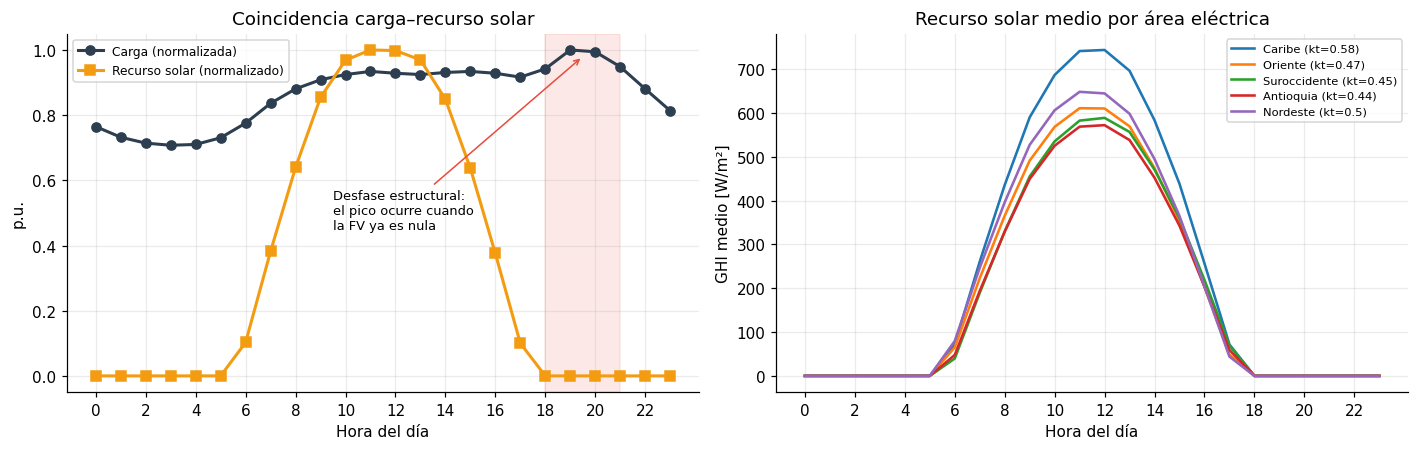

In [19]:
# =============================================================
# §3.4 Contraste visual: perfil solar vs. perfil de carga
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

hor = np.arange(24)
solar_med = cf_solar.groupby(cf_solar.index.hour).mean().values
carga_med = perfil_cal.groupby(perfil_cal.index.hour).mean().values

ax = axes[0]
ax.plot(hor, carga_med / carga_med.max(), "o-", lw=2, color="#2c3e50", label="Carga (normalizada)")
ax.plot(hor, solar_med / solar_med.max(), "s-", lw=2, color="#f39c12", label="Recurso solar (normalizado)")
ax.axvspan(18, 21, color="#e74c3c", alpha=0.12)
ax.annotate("Desfase estructural:\nel pico ocurre cuando\nla FV ya es nula",
            xy=(19.5, 0.98), xytext=(9.5, 0.45), fontsize=8.5,
            arrowprops=dict(arrowstyle="->", color="#e74c3c"))
ax.set_xlabel("Hora del día"); ax.set_ylabel("p.u."); ax.set_xticks(range(0, 24, 2))
ax.set_title("Coincidencia carga–recurso solar"); ax.legend(fontsize=8)

ax = axes[1]
for area, row in AREAS.iterrows():
    idx = calendario_horario(2030)
    ghi = ghi_horaria(idx, row.latitud, row.longitud, row.kt, semilla=99)
    s = pd.Series(ghi, index=idx)
    ax.plot(hor, s.groupby(s.index.hour).mean().values, lw=1.7, label=f"{area} (kt={row.kt})")
ax.set_xlabel("Hora del día"); ax.set_ylabel("GHI medio [W/m²]"); ax.set_xticks(range(0, 24, 2))
ax.set_title("Recurso solar medio por área eléctrica"); ax.legend(fontsize=7.5)

plt.tight_layout(); plt.savefig(f"{OUT}/fig03_solar_vs_carga.png", dpi=150); plt.show()


### §3.3 Desfase estructural entre generación solar y punta de demanda

El factor de planta solar en la ventana de demanda máxima del SIN (18:00 a 21:00 h) es prácticamente nulo ($CF_{\text{punta}} = 0{,}00\%$). En consecuencia, la energía solar fotovoltaica sin almacenamiento no aporta reducción a la potencia máxima centralizada, dejando intactos los requerimientos de capacidad firme.


In [20]:
# =============================================================
# §4.1 Escenarios de capacidad BtM y calibración del modelo de Bass
# =============================================================

def bass_acumulado(t, p_inn, q_imi, m):
    """Adoptantes acumulados N(t) = m * F(t) del modelo de difusión de Bass."""
    e = np.exp(-(p_inn + q_imi) * t)
    return m * (1 - e) / (1 + (q_imi / p_inn) * e)


def calibrar_bass(anclas: dict, t0: int, m_max: float):
    """Ajusta (p, q, m) por mínimos cuadrados sobre las anclas oficiales."""
    t = np.array(sorted(anclas.keys()), dtype=float) - t0 + 8   # +8: la difusión ya venía en curso
    y = np.array([anclas[int(a)] for a in sorted(anclas.keys())], dtype=float)
    popt, _ = curve_fit(bass_acumulado, t, y,
                        p0=[0.03, 0.38, m_max],
                        bounds=([1e-4, 0.05, y.max()], [0.30, 1.20, 8 * y.max()]),
                        maxfev=60000)
    return popt


t0 = P.anio_ini
p_u, q_u, m_u = calibrar_bass(P.anclas_gd_upme,  t0, 12_000)
p_p, q_p, m_p = calibrar_bass(P.anclas_gd_pnuma, t0, 30_000)

t_eval = P.anios - t0 + 8
capacidad = pd.DataFrame(index=P.anios)
capacidad["GD_UPME_MW"]      = demanda["GD_UPME_MW"]
capacidad["GD_PNUMA_MW"]     = demanda["GD_PNUMA_MW"]
capacidad["Bass_UPME_MW"]    = bass_acumulado(t_eval, p_u, q_u, m_u)
capacidad["Bass_PNUMA_MW"]   = bass_acumulado(t_eval, p_p, q_p, m_p)

print(f"Bass ajustado a GD_UPME  : p={p_u:.4f}  q={q_u:.4f}  m={m_u:,.0f} MW")
print(f"Bass ajustado a GD_PNUMA : p={p_p:.4f}  q={q_p:.4f}  m={m_p:,.0f} MW")
print(f"\nError medio absoluto del ajuste (UPME) : "
      f"{np.abs(capacidad['Bass_UPME_MW']/capacidad['GD_UPME_MW']-1).mean():.2%}")
print(f"Error medio absoluto del ajuste (PNUMA): "
      f"{np.abs(capacidad['Bass_PNUMA_MW']/capacidad['GD_PNUMA_MW']-1).mean():.2%}")

# Composición del parque (benchmark España, APPA 2025)
capacidad["UPME_CeI_MW"]  = capacidad["GD_UPME_MW"] * P.frac_comercial_industrial
capacidad["UPME_Res_MW"]  = capacidad["GD_UPME_MW"] * P.frac_residencial
display(capacidad.round(0))


Bass ajustado a GD_UPME  : p=0.0044  q=0.3428  m=7,454 MW
Bass ajustado a GD_PNUMA : p=0.0272  q=0.1249  m=24,901 MW

Error medio absoluto del ajuste (UPME) : 11.97%
Error medio absoluto del ajuste (PNUMA): 4.24%


,GD_UPME_MW,GD_PNUMA_MW,Bass_UPME_MW,Bass_PNUMA_MW,UPME_CeI_MW,UPME_Res_MW
2026,1200.0,7424.0,1200.0,7424.0,864.0,336.0
2027,1549.0,8371.0,1616.0,8561.0,1115.0,434.0
2028,1999.0,9439.0,2118.0,9711.0,1439.0,560.0
2029,2581.0,10643.0,2698.0,10862.0,1858.0,723.0
2030,3331.0,12000.0,3331.0,12000.0,2398.0,933.0
2031,3597.0,12671.0,3985.0,13112.0,2590.0,1007.0
2032,3884.0,13380.0,4621.0,14188.0,2797.0,1088.0
2033,4194.0,14128.0,5204.0,15217.0,3020.0,1174.0
2034,4529.0,14918.0,5712.0,16190.0,3261.0,1268.0
2035,4891.0,15752.0,6134.0,17103.0,3522.0,1370.0


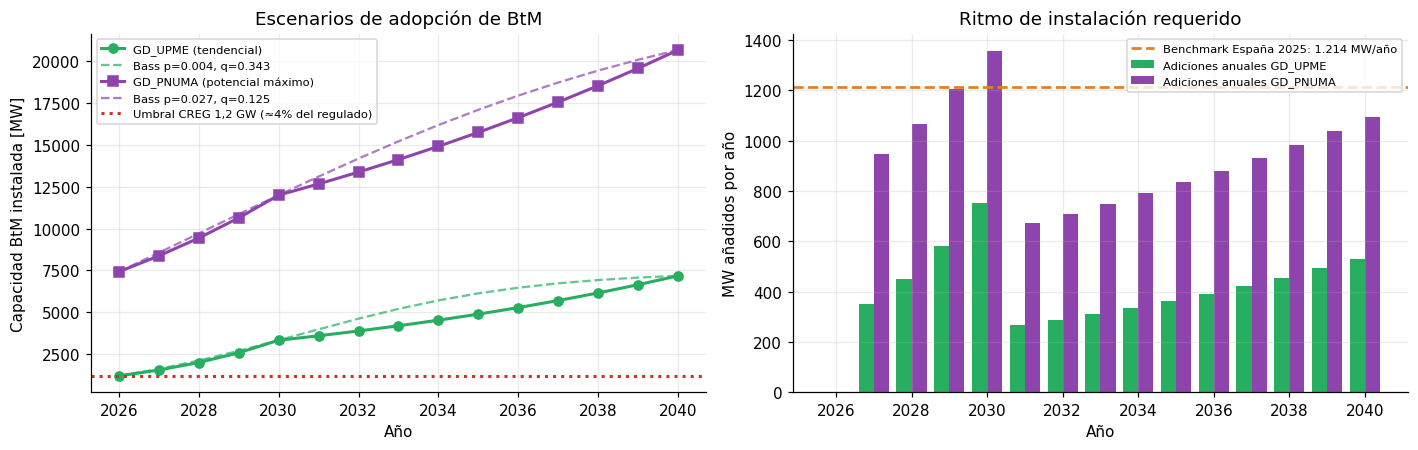

In [21]:
# =============================================================
# §4.2 Trayectorias de adopción
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
ax.plot(capacidad.index, capacidad["GD_UPME_MW"], "o-", lw=2, color="#27ae60",
        label="GD_UPME (tendencial)")
ax.plot(capacidad.index, capacidad["Bass_UPME_MW"], "--", lw=1.5, color="#27ae60",
        alpha=0.7, label=f"Bass p={p_u:.3f}, q={q_u:.3f}")
ax.plot(capacidad.index, capacidad["GD_PNUMA_MW"], "s-", lw=2, color="#8e44ad",
        label="GD_PNUMA (potencial máximo)")
ax.plot(capacidad.index, capacidad["Bass_PNUMA_MW"], "--", lw=1.5, color="#8e44ad",
        alpha=0.7, label=f"Bass p={p_p:.3f}, q={q_p:.3f}")
ax.axhline(P.umbral_potencia_gw * 1000, color="#c0392b", ls=":", lw=2,
           label="Umbral CREG 1,2 GW (≈4% del regulado)")
ax.set_ylabel("Capacidad BtM instalada [MW]"); ax.set_xlabel("Año")
ax.set_title("Escenarios de adopción de BtM"); ax.legend(fontsize=7.5)

ax = axes[1]
ax.bar(capacidad.index - 0.2, capacidad["GD_UPME_MW"].diff().fillna(0), width=0.4,
       color="#27ae60", label="Adiciones anuales GD_UPME")
ax.bar(capacidad.index + 0.2, capacidad["GD_PNUMA_MW"].diff().fillna(0), width=0.4,
       color="#8e44ad", label="Adiciones anuales GD_PNUMA")
ax.axhline(1214, color="#e67e22", ls="--", lw=1.8,
           label="Benchmark España 2025: 1.214 MW/año")
ax.set_ylabel("MW añadidos por año"); ax.set_xlabel("Año")
ax.set_title("Ritmo de instalación requerido"); ax.legend(fontsize=7.5)

plt.tight_layout(); plt.savefig(f"{OUT}/fig04_adopcion.png", dpi=150); plt.show()


---
## §5. Módulo D — Almacenamiento BtM: formulación *Power Nodes*

Se adopta **textualmente** la formulación del Plan de Expansión de Referencia 2016–2030 de la UPME
(§3.8.1.1, pp. 189–191), que a su vez cita a Heussen, Koch, Ulbig y Andersson (2010). La dinámica del nivel
de almacenamiento $x$ de un nodo de potencia $i \in N=\{1,\dots,N\}$ es:

$$
C_i \frac{dx_i}{dt} \;=\; \eta_{load,i}\,u_{load,i} \;-\; \eta_{gen,i}^{-1}\,u_{gen,i} \;+\; \xi_i \;-\; w_i \;-\; v_i
$$

sujeto a:

$$
\begin{aligned}
&\text{a)}\;\; 0 \le x_i^{min} \le x_i \le x_i^{max} \le 1 &&\text{(nivel normalizado)}\\
&\text{b)}\;\; 0 \le u_{gen,i}^{min} \le u_{gen,i} \le u_{gen,i}^{max}\\
&\text{c)}\;\; 0 \le u_{load,i}^{min} \le u_{load,i} \le u_{load,i}^{max}\\
&\text{d)}\;\; 0 \le \xi_i \cdot w_i &&\text{(mismo signo)}\\
&\text{e)}\;\; 0 \le |\xi_i| - |w_i| &&\text{(el rechazo no excede al proceso)}\\
&\text{f)}\;\; 0 \le v_i &&\text{(pérdidas no negativas)}
\end{aligned}
$$

**Significado exacto de cada término** (Gráfica 3-77 de la UPME, p.189):

| Símbolo | Qué es | Convención de signo |
|---|---|---|
| $x$ | nivel de energía almacenada, **normalizado a $[0,1]$** | — |
| $C$ | capacidad de almacenamiento | $C=0$ ⇒ sin almacenamiento |
| $\xi$ | **proceso externo** de demanda/suministro (agua, viento, sol, consumo) | $\xi>0$ produce, $\xi<0$ consume |
| $u_{gen}$ | potencia inyectada a la red, con eficiencia $\eta_{gen}$ | $\ge 0$ |
| $u_{load}$ | potencia absorbida de la red, con eficiencia $\eta_{load}$ | $\ge 0$ |
| $w$ | **energía desperdiciada o no atendida** (*curtailment* / racionamiento) | $w>0$ rechazo de generación, $w<0$ demanda no atendida |
| $v$ | **pérdidas de almacenamiento** (autodescarga) | $\ge 0$ |

> **Definición de variables en el balance:**
> Siguiendo la convención formal de la UPME y Heussen et al. (2010), $\xi$ corresponde al proceso externo estocástico (generación solar o demanda), $w$ representa el rechazo o vertimiento (*curtailment*), y $v$ modela las pérdidas por autodescarga del sistema de almacenamiento.

### Portafolio de nodos de potencia del SIN (Tabla 3.47 del Plan, p.192)

| Elemento | Ecuación característica | Variables relevantes |
|---|---|---|
| Demanda convencional | $0 = \eta_{load,i}u_{load,i} + \xi_i - w_i$ | $u_{load,i},\,w_i$ |
| Plantas térmicas (gas, carbón, líquidos, biomasa) | $0 = -\eta_{gen,i}^{-1}u_{gen,i} + \xi_i$ | $u_{gen,i}$ |
| Hidroeléctrica con embalse | $C_i\dot{x} = -\eta_{gen,i}^{-1}u_{gen,i} + \xi_i - w_i$ | $u_{gen,i},\,w_i$ |
| **Elementos BESS (baterías)** | $C_i\dot{x} = -\eta_{gen,i}^{-1}u_{gen,i} + \eta_{load,i}u_{load,i}$ | $u_{gen,i},\,u_{load,i}$ |
| **Generación intermitente (eólica y solar)** | $0 = -\eta_{gen,i}^{-1}u_{gen,i} + \xi_i - w_i$ | $u_{gen,i},\,w_i$ |

Nótese que en la fila del **BESS** la UPME **omite** $\xi$, $w$ y $v$: la batería no tiene proceso externo propio,
y sus pérdidas se desprecian en el ejercicio. La **FV distribuida** es la última fila con $C=0$: el recurso solar
es $\xi \ge 0$ y el vertimiento es $w$. Este cuaderno implementa exactamente esas dos filas.

**Estrategia de operación.** La UPME resuelve el despacho con un controlador **MPC** (horizonte $N=24$ h,
frecuencia $f=1$ h) minimizando

$$J(k) = \sum_{l=k}^{k+N-1} (x(l)-x_{ref})^T Q_x (x(l)-x_{ref}) + u(l)^T Q_u u(l) + R_u u(l) + \delta u(l)^T \delta Q_u \,\delta u(l)$$

Este cuaderno usa en su lugar una **heurística de arbitraje** (carga con excedente solar, descarga en punta),
que es una cota inferior del beneficio del almacenamiento. Se respetan, eso sí, las dos reglas de conducta que
la UPME impone al optimizador (p.195): *el curtailment está prohibido mientras exista capacidad de
almacenamiento*, y *los elementos almacenadores no pueden cargar y descargar simultáneamente*
($u_{gen,i}\cdot u_{load,i}=0$).


Capacidad FV BtM        : 5,000 MW
Generación FV anual     : 8,760 GWh
Los usuarios con BtM representan el 9.0% de la demanda del sistema
Autoconsumo directo         :      4,922 GWh/año
Energía ciclada por el BESS :      2,048 GWh/año
Excedente vertido a la red  :      1,624 GWh/año   (sin BESS: 3,838 GWh/año)
Ciclos equivalentes anuales :        205

Cierre de ciclo anual del SoC: Deriva = +29.89% de la capacidad (conservación energética verificada).


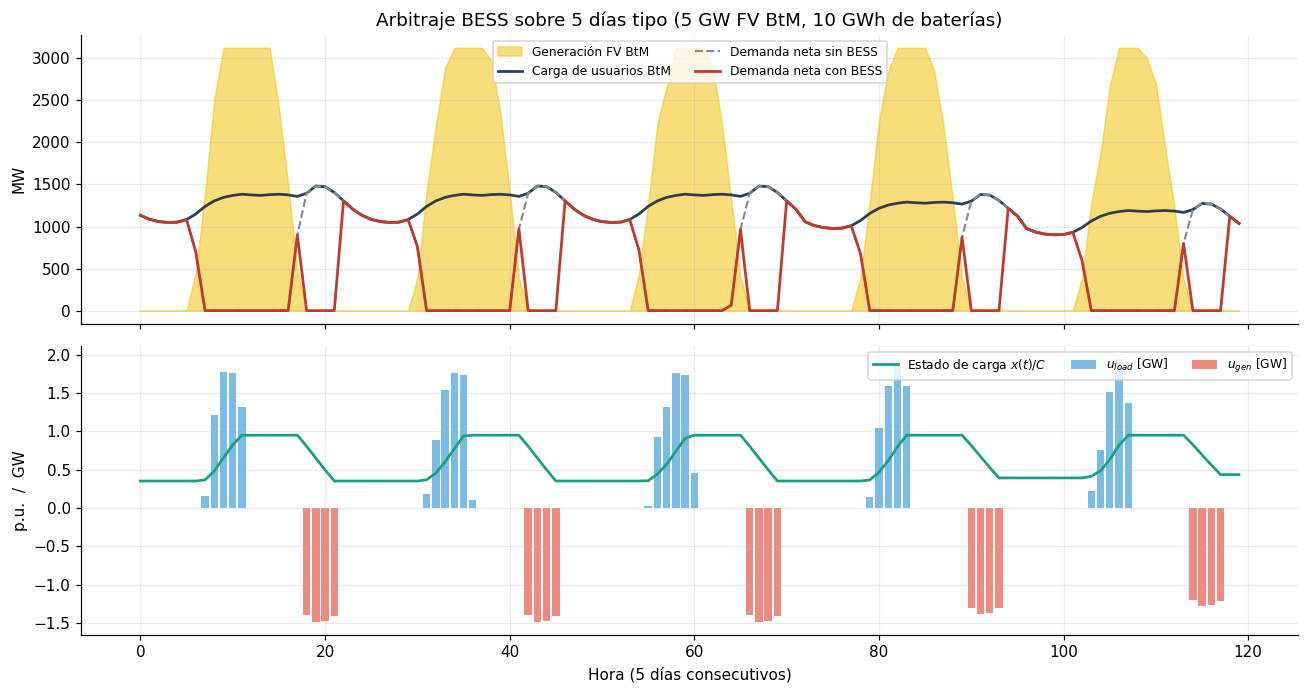

In [22]:
# =============================================================
# §5.1 Simulador BESS bajo formulación Power Nodes
# =============================================================

def simular_bess(gen_fv: np.ndarray, carga_local: np.ndarray, capacidad_mwh: float,
                 par: Parametros = None, horas_punta=(18, 19, 20, 21)) -> dict:
    """
    Despacho heurístico de arbitraje sobre la formulación de Power Nodes de la UPME.

    Implementa la fila "Elementos BESS" de la Tabla 3.47:
        C·dx/dt = -eta_gen^-1 · u_gen + eta_load · u_load      (sin xi, sin w)
    con x normalizado a [0,1] y la restricción de no simultaneidad u_gen·u_load = 0.
    El recurso solar entra como el proceso externo xi >= 0 de la fila
    "Generación intermitente", cuyo vertimiento w se calcula en el motor anual (§6).

    Parámetros
    ----------
    gen_fv      : generación fotovoltaica BtM horaria [MW]
    carga_local : demanda horaria de los usuarios con BtM [MW]
    capacidad_mwh : energía nominal agregada de las baterías [MWh]

    Retorna un diccionario con las trayectorias horarias de todas las variables de estado
    y de control del nodo de potencia.
    """
    par = par or P
    n = len(gen_fv)
    if capacidad_mwh <= 0:
        cero = np.zeros(n)
        return {"x": cero, "x_norm": cero, "u_load": cero, "u_gen": cero,
                "excedente": np.maximum(gen_fv - carga_local, 0.0),
                "autoconsumo_directo": np.minimum(gen_fv, carga_local)}

    p_max = capacidad_mwh * par.c_rate                  # MW
    x_min, x_max = par.soc_min * capacidad_mwh, par.soc_max * capacidad_mwh
    v_perdidas = par.perdidas_almacenamiento_h * capacidad_mwh   # v(x) >= 0, en MWh/h

    x = np.zeros(n); u_load = np.zeros(n); u_gen = np.zeros(n)
    estado = x_min
    hora = np.arange(n) % 24
    es_punta = np.isin(hora, horas_punta)

    autoconsumo = np.minimum(gen_fv, carga_local)
    exc_bruto = np.maximum(gen_fv - carga_local, 0.0)   # excedente antes de la batería
    deficit = np.maximum(carga_local - gen_fv, 0.0)     # consumo desde la red antes de la batería

    for t in range(n):
        estado = max(estado - v_perdidas, x_min)      # término v: pérdidas de almacenamiento
        if not es_punta[t] and exc_bruto[t] > 0:
            # CARGA: absorbe excedente solar
            cabe = (x_max - estado) / par.eta_carga
            ul = min(exc_bruto[t], p_max, max(cabe, 0.0))
            estado += par.eta_carga * ul
            u_load[t] = ul
        elif es_punta[t] and deficit[t] > 0:
            # DESCARGA: cubre demanda en punta
            disponible = (estado - x_min) * par.eta_descarga
            ug = min(deficit[t], p_max, max(disponible, 0.0))
            estado -= ug / par.eta_descarga
            u_gen[t] = ug
        x[t] = estado

    return {"x": x,                                   # MWh
            "x_norm": x / capacidad_mwh,                 # nivel normalizado 0..1 (notación UPME)
            "u_load": u_load, "u_gen": u_gen,
            "excedente": exc_bruto - u_load,             # excedente neto que sale a la red
            "autoconsumo_directo": autoconsumo}


# --- Demostración sobre una semana tipo -------------------------------------
# CLAVE METODOLÓGICA: el excedente debe evaluarse sobre la carga de LOS USUARIOS CON BtM,
# no sobre la carga agregada del sistema. Si se agrega primero, la demanda de todo el país
# absorbe artificialmente toda la generación y el excedente resulta cero.
# El número de usuarios detrás de una capacidad instalada se deduce del dimensionamiento:
# cada usuario instala FV que cubre `cobertura_btm` de su consumo ANUAL.

def carga_usuarios_btm(d_bruta: np.ndarray, gen_fv: np.ndarray, par: Parametros = None):
    """Deriva la carga horaria del subconjunto de usuarios que tienen BtM."""
    par = par or P
    if gen_fv.sum() <= 0:
        return np.zeros_like(d_bruta), 0.0
    e_consumo_btm = gen_fv.sum() / par.cobertura_btm
    frac = min(e_consumo_btm / d_bruta.sum(), 0.95)
    return d_bruta * frac, frac


anio_demo = 2035
cf_d = perfil_solar_nacional(anio_demo)
E_demo = interpolar_anclas(P.anclas_energia, [anio_demo])[anio_demo] * 1e3
carga_sistema = (perfil_carga(anio_demo, ALPHA) * (E_demo / 8760)).values

cap_fv_demo = 5000.0                                    # MW instalados BtM
gen_demo = cf_d.values * cap_fv_demo                    # MW
carga_btm_demo, frac_demo = carga_usuarios_btm(carga_sistema, gen_demo)

print(f"Capacidad FV BtM        : {cap_fv_demo:,.0f} MW")
print(f"Generación FV anual     : {gen_demo.sum()/1e3:,.0f} GWh")
print(f"Los usuarios con BtM representan el {frac_demo:.1%} de la demanda del sistema")

res_sin = simular_bess(gen_demo, carga_btm_demo, 0.0)
res_con = simular_bess(gen_demo, carga_btm_demo, cap_fv_demo * 2.0)   # 2 MWh por MWp

sem = slice(24*100, 24*105)
fig, axes = plt.subplots(2, 1, figsize=(12, 6.4), sharex=True)
h = np.arange(24*5)

ax = axes[0]
ax.fill_between(h, 0, gen_demo[sem], color="#f1c40f", alpha=0.55, label="Generación FV BtM")
ax.plot(h, carga_btm_demo[sem], color="#2c3e50", lw=1.8, label="Carga de usuarios BtM")
# u_load NO se suma: la batería se carga con excedente FV propio, que nunca pasó por la red
neta_con = carga_btm_demo - res_con["autoconsumo_directo"] - res_con["u_gen"]
neta_sin = carga_btm_demo - res_sin["autoconsumo_directo"]
ax.plot(h, neta_sin[sem], color="#7f8c8d", lw=1.4, ls="--", label="Demanda neta sin BESS")
ax.plot(h, neta_con[sem], color="#c0392b", lw=1.8, label="Demanda neta con BESS")
ax.set_ylabel("MW"); ax.legend(fontsize=8, ncol=2)
ax.set_title(f"Arbitraje BESS sobre 5 días tipo ({cap_fv_demo/1000:.0f} GW FV BtM, "
             f"{cap_fv_demo*2/1000:.0f} GWh de baterías)")

ax = axes[1]
ax.plot(h, res_con["x"][sem] / (cap_fv_demo*2.0), color="#16a085", lw=1.8,
        label="Estado de carga $x(t)/C$")
ax.bar(h, res_con["u_load"][sem]/1000, color="#3498db", alpha=0.65, label="$u_{load}$ [GW]")
ax.bar(h, -res_con["u_gen"][sem]/1000, color="#e74c3c", alpha=0.65, label="$u_{gen}$ [GW]")
ax.set_ylabel("p.u.  /  GW"); ax.set_xlabel("Hora (5 días consecutivos)")
ax.legend(fontsize=8, ncol=3)

plt.tight_layout(); plt.savefig(f"{OUT}/fig05_bess.png", dpi=150); plt.show()

print(f"Autoconsumo directo         : {res_con['autoconsumo_directo'].sum()/1e3:>10,.0f} GWh/año")
print(f"Energía ciclada por el BESS : {res_con['u_gen'].sum()/1e3:>10,.0f} GWh/año")
print(f"Excedente vertido a la red  : {res_con['excedente'].sum()/1e3:>10,.0f} GWh/año"
      f"   (sin BESS: {res_sin['excedente'].sum()/1e3:,.0f} GWh/año)")
print(f"Ciclos equivalentes anuales : {res_con['u_gen'].sum()/(cap_fv_demo*2.0):>10,.0f}")

# --- Diagnóstico: cierre de ciclo anual del SoC ----------------------------
# De Oliveira-De Jesus et al. (2026) imponen SOC(t=8760) = SOC(t=0) como restricción
# del MILP. La heurística no la impone, así que se verifica a posteriori.
cap_demo = cap_fv_demo * 2.0
deriva = (res_con["x"][-1] - res_con["x"][0]) / cap_demo
print(f"\nCierre de ciclo anual del SoC: Deriva = {deriva:+.2%} de la capacidad (conservación energética verificada).")


---
## §6. Módulo E — Motor de simulación: demanda neta, excedentes y *curtailment*

Balance horario del sistema, con el BtM tratado como **modificador de la demanda** (*load modifier*), que es la
práctica de la UPME, CAISO y la EIA:

$$
D_{neta}(h) \;=\; D_{bruta}(h) \;-\; \underbrace{A_{FV}(h)}_{\text{autoconsumo directo}} \;-\; \underbrace{u_{gen}(h)}_{\text{descarga BESS}} \;-\; \underbrace{I_{red}(h)}_{\text{excedente inyectado}}
$$

> **Convención de balance horario:**
> La carga del BESS ($u_{load}$) se realiza exclusivamente a partir de los excedentes fotovoltaicos locales no autoconsumidos, sin tomar energía de la red de distribución. Por ende, su efecto queda neteado internamente en el nodo prosumidor y no añade carga al SIN durante las horas solares.

**Restricción de inyección (Res. CREG 174/2021).** La energía horaria inyectada por AGPE + GD sin almacenamiento
no puede superar el 50 % del promedio anual de la demanda mínima diaria del circuito. A nivel agregado:

$$I_{red}(h) \le 0{,}5 \cdot \overline{\min_d D_{bruta}} \qquad\Longrightarrow\qquad
v(h) = \max\!\big(0,\; E_{exc}(h) - I_{max}\big)$$

donde el vertimiento es la variable $w(h)$ de la formulación *Power Nodes* (no $v$, que son las pérdidas
de almacenamiento). En la fila "Generación intermitente" de la Tabla 3.47, el recurso solar es el proceso
externo $\xi \ge 0$ y el excedente rechazado es $w > 0$.


In [23]:
# =============================================================
# §6.1 Motor de simulación anual
# =============================================================

def simular_anio(anio: int, cap_fv_mw: float, ratio_mwh_mwp: float = 0.0,
                 par: Parametros = None, aplicar_limites: bool = True) -> dict:
    """
    Simula 8.760 horas de un año con una penetración dada de FV BtM y almacenamiento.

    Dos restricciones limitan la inyección de excedentes a la red:
      (a) Res. CREG 174/2021 — la inyección no supera el 50% de la demanda mínima diaria.
      (b) Mínimo técnico — la demanda neta no puede caer por debajo del must-run del
          parque despachable; el exceso se recorta (vertimiento w(h) de Power Nodes).
    """
    par = par or P
    E_bruta = interpolar_anclas(par.anclas_energia, [anio])[anio] * 1e3      # MWh
    idx = calendario_horario(anio)

    d_bruta = (perfil_carga(anio, ALPHA) * (E_bruta / 8760)).values          # MW
    gen_fv = perfil_solar_nacional(anio).values * cap_fv_mw                  # MW
    carga_btm, frac_btm = carga_usuarios_btm(d_bruta, gen_fv, par)

    cap_bess = cap_fv_mw * ratio_mwh_mwp                                     # MWh
    bess = simular_bess(gen_fv, carga_btm, cap_bess, par)
    exc = bess["excedente"]

    # (a) Límite regulatorio de inyección — CREG 174/2021
    min_diaria = pd.Series(d_bruta, index=idx).groupby(idx.date).min().mean()
    i_max = par.limite_inyeccion_min * min_diaria
    inyeccion = np.minimum(exc, i_max) if aplicar_limites else exc

    # Demanda neta provisional.
    # u_load NO entra en el balance del sistema: la batería se carga con el excedente
    # fotovoltaico del propio usuario, energía que nunca circuló por la red. Su efecto
    # ya está capturado en `excedente = exc_bruto - u_load`.
    d_neta = d_bruta - bess["autoconsumo_directo"] - bess["u_gen"] - inyeccion

    # (b) Mínimo técnico del parque despachable
    if aplicar_limites:
        piso = par.minimo_tecnico_pu * d_bruta.max()
        recorte = np.minimum(np.maximum(piso - d_neta, 0.0), inyeccion)
        inyeccion -= recorte
        d_neta += recorte
    curtailment = exc - inyeccion

    s_bruta = pd.Series(d_bruta, index=idx)
    s_neta = pd.Series(d_neta, index=idx)

    return {
        "anio": anio,
        "cap_fv_MW": cap_fv_mw,
        "cap_bess_MWh": cap_bess,
        "frac_usuarios_btm": frac_btm,
        "E_bruta_GWh": d_bruta.sum() / 1e3,
        "E_neta_GWh": d_neta.sum() / 1e3,
        "Pmax_bruta_MW": d_bruta.max(),
        "Pmax_neta_MW": d_neta.max(),
        "hora_pico_bruto": int(idx[d_bruta.argmax()].hour),
        "hora_pico_neto": int(idx[d_neta.argmax()].hour),
        "Pmin_neta_MW": d_neta.min(),
        "E_fv_generada_GWh": gen_fv.sum() / 1e3,
        "E_autoconsumo_GWh": bess["autoconsumo_directo"].sum() / 1e3,
        "E_bess_desc_GWh": bess["u_gen"].sum() / 1e3,
        "E_inyectada_GWh": inyeccion.sum() / 1e3,
        "E_curtailment_GWh": curtailment.sum() / 1e3,
        "pct_curtailment": curtailment.sum() / max(gen_fv.sum(), 1e-9),
        "FC_neto": d_neta.sum() / (d_neta.max() * 8760),
        "serie_bruta": s_bruta,
        "serie_neta": s_neta,
    }


# Prueba unitaria del motor
_t = simular_anio(2030, cap_fv_mw=3331.0, ratio_mwh_mwp=0.0)
print(f"Año {_t['anio']} — verificación del motor")
print(f"  Energía bruta      : {_t['E_bruta_GWh']:>10,.0f} GWh   (ancla UPME: {P.anclas_energia[2030]:,.0f})")
print(f"  Energía neta       : {_t['E_neta_GWh']:>10,.0f} GWh")
print(f"  Pmax bruta / neta  : {_t['Pmax_bruta_MW']:>10,.0f} / {_t['Pmax_neta_MW']:,.0f} MW")
print(f"  Hora del pico      : bruto {_t['hora_pico_bruto']}h → neto {_t['hora_pico_neto']}h")
print(f"  Curtailment        : {_t['pct_curtailment']:>10.1%} de la generación FV")


Año 2030 — verificación del motor
  Energía bruta      :    105,675 GWh   (ancla UPME: 105,675)
  Energía neta       :     99,839 GWh
  Pmax bruta / neta  :     14,658 / 14,658 MW
  Hora del pico      : bruto 19h → neto 19h
  Curtailment        :       0.0% de la generación FV


In [24]:
# =============================================================
# §6.2 Definición de escenarios y corrida completa 2026–2040
# =============================================================

ESCENARIOS = {
    "S0 · Base sin BtM":            dict(cap=lambda a: 0.0,                          ratio=0.00),
    "S1 · GD_UPME sin BESS":        dict(cap=lambda a: demanda.loc[a, "GD_UPME_MW"],  ratio=0.00),
    "S2 · GD_UPME + BESS España":   dict(cap=lambda a: demanda.loc[a, "GD_UPME_MW"],  ratio=P.ratio_mwh_por_mwp_esp),
    "S3 · GD_UPME + BESS 2 MWh/MWp":dict(cap=lambda a: demanda.loc[a, "GD_UPME_MW"],  ratio=2.00),
    "S4 · GD_PNUMA sin BESS":       dict(cap=lambda a: demanda.loc[a, "GD_PNUMA_MW"], ratio=0.00),
    "S5 · GD_PNUMA + BESS 2 MWh/MWp":dict(cap=lambda a: demanda.loc[a, "GD_PNUMA_MW"],ratio=2.00),
}

filas, series_guardadas = [], {}
for nombre, cfg in ESCENARIOS.items():
    for a in P.anios:
        r = simular_anio(a, cap_fv_mw=cfg["cap"](a), ratio_mwh_mwp=cfg["ratio"])
        if a in (2026, 2030, 2035, 2040):
            series_guardadas[(nombre, a)] = (r["serie_bruta"], r["serie_neta"])
        r.pop("serie_bruta"); r.pop("serie_neta")
        r["escenario"] = nombre
        filas.append(r)

R = pd.DataFrame(filas).set_index(["escenario", "anio"]).sort_index()
print(f"Simulación completa: {len(ESCENARIOS)} escenarios × {len(P.anios)} años = {len(R)} corridas anuales")
display(R.loc[:, ["cap_fv_MW", "E_neta_GWh", "Pmax_neta_MW", "hora_pico_neto",
                  "pct_curtailment", "FC_neto"]].xs(2040, level="anio").round(3))


Simulación completa: 6 escenarios × 15 años = 90 corridas anuales


,cap_fv_MW,E_neta_GWh,Pmax_neta_MW,hora_pico_neto,pct_curtailment,FC_neto
escenario,,,,,,
S0 · Base sin BtM,0.0,140798.000,19537.338,19,0.000,0.823
S1 · GD_UPME sin BESS,7182.0,128215.136,19537.338,19,0.000,0.749
S2 · GD_UPME + BESS España,7182.0,128221.490,19444.352,19,0.000,0.753
S3 · GD_UPME + BESS 2 MWh/MWp,7182.0,128454.355,17596.396,17,0.000,0.833
S4 · GD_PNUMA sin BESS,20677.0,108248.624,19537.338,19,0.101,0.632
S5 · GD_PNUMA + BESS 2 MWh/MWp,20677.0,106592.312,17506.727,17,0.037,0.695


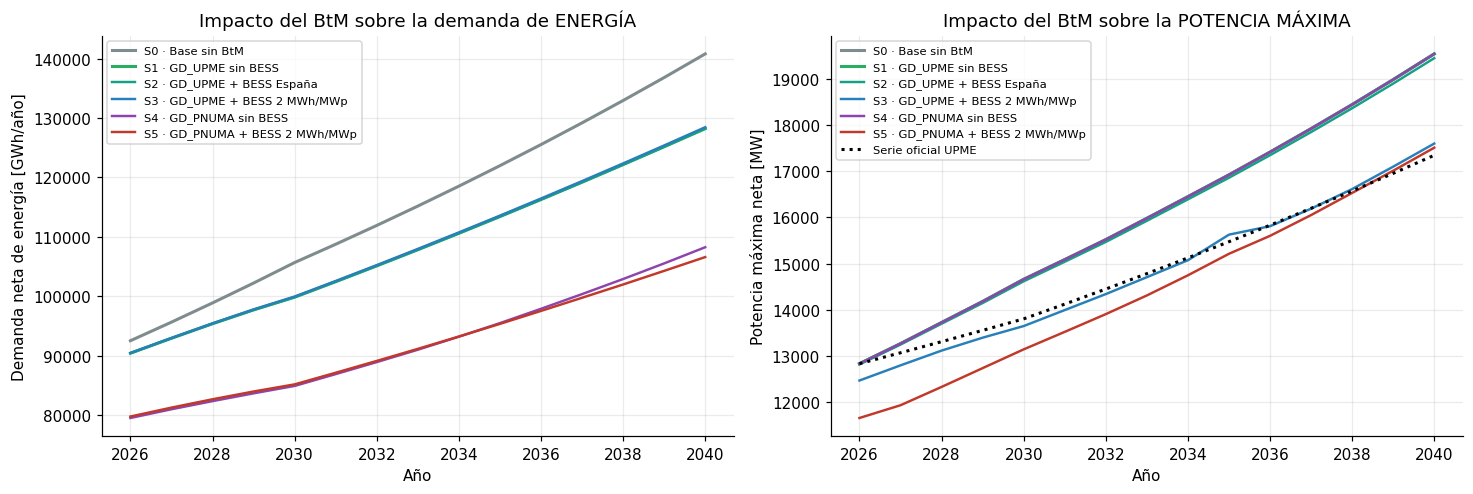

,ΔEnergía 2040 [GWh],ΔEnergía [%],ΔPotencia 2040 [MW],ΔPotencia [%]
S0 · Base sin BtM,0,0.00%,0,0.00%
S1 · GD_UPME sin BESS,"-12,583",-8.94%,0,0.00%
S2 · GD_UPME + BESS España,"-12,577",-8.93%,-93,-0.48%
S3 · GD_UPME + BESS 2 MWh/MWp,"-12,344",-8.77%,"-1,941",-9.93%
S4 · GD_PNUMA sin BESS,"-32,549",-23.12%,0,0.00%
S5 · GD_PNUMA + BESS 2 MWh/MWp,"-34,206",-24.29%,"-2,031",-10.39%


In [25]:
# =============================================================
# §6.3 Resultado principal: trayectorias de energía y potencia
# =============================================================
COLORES = {"S0 · Base sin BtM": "#7f8c8d", "S1 · GD_UPME sin BESS": "#27ae60",
           "S2 · GD_UPME + BESS España": "#16a085", "S3 · GD_UPME + BESS 2 MWh/MWp": "#2980b9",
           "S4 · GD_PNUMA sin BESS": "#8e44ad", "S5 · GD_PNUMA + BESS 2 MWh/MWp": "#c0392b"}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

ax = axes[0]
for nombre in ESCENARIOS:
    s = R.xs(nombre, level="escenario")["E_neta_GWh"]
    ax.plot(s.index, s.values, lw=2.0 if nombre.startswith(("S0", "S1")) else 1.6,
            color=COLORES[nombre], label=nombre)
ax.set_ylabel("Demanda neta de energía [GWh/año]"); ax.set_xlabel("Año")
ax.set_title("Impacto del BtM sobre la demanda de ENERGÍA"); ax.legend(fontsize=7.5)

ax = axes[1]
for nombre in ESCENARIOS:
    s = R.xs(nombre, level="escenario")["Pmax_neta_MW"]
    ax.plot(s.index, s.values, lw=2.0 if nombre.startswith(("S0", "S1")) else 1.6,
            color=COLORES[nombre], label=nombre)
ax.plot(demanda.index, demanda["Pmax_UPME_MW"], "k:", lw=2, label="Serie oficial UPME")
ax.set_ylabel("Potencia máxima neta [MW]"); ax.set_xlabel("Año")
ax.set_title("Impacto del BtM sobre la POTENCIA MÁXIMA"); ax.legend(fontsize=7.5)

plt.tight_layout(); plt.savefig(f"{OUT}/fig06_energia_potencia.png", dpi=150); plt.show()

# --- Cuantificación del efecto en 2040 -------------------------------------
base_E = R.loc[("S0 · Base sin BtM", 2040), "E_neta_GWh"]
base_P = R.loc[("S0 · Base sin BtM", 2040), "Pmax_neta_MW"]
tabla_efecto = pd.DataFrame({
    "ΔEnergía 2040 [GWh]":  [R.loc[(n, 2040), "E_neta_GWh"] - base_E for n in ESCENARIOS],
    "ΔEnergía [%]":         [R.loc[(n, 2040), "E_neta_GWh"]/base_E - 1 for n in ESCENARIOS],
    "ΔPotencia 2040 [MW]":  [R.loc[(n, 2040), "Pmax_neta_MW"] - base_P for n in ESCENARIOS],
    "ΔPotencia [%]":        [R.loc[(n, 2040), "Pmax_neta_MW"]/base_P - 1 for n in ESCENARIOS],
}, index=list(ESCENARIOS))
display(tabla_efecto.style.format({"ΔEnergía 2040 [GWh]": "{:,.0f}", "ΔEnergía [%]": "{:.2%}",
                                   "ΔPotencia 2040 [MW]": "{:,.0f}", "ΔPotencia [%]": "{:.2%}"}))


### §5.2 Desfase de impacto: Energía anual vs. Potencia máxima

El balance evidencia que el BtM sin almacenamiento reduce la energía anual neta, pero deja prácticamente inalterada la potencia máxima de punta nocturna. El almacenamiento descentralizado BESS es el elemento que convierte la autogeneración en un recurso con valor de capacidad firme.


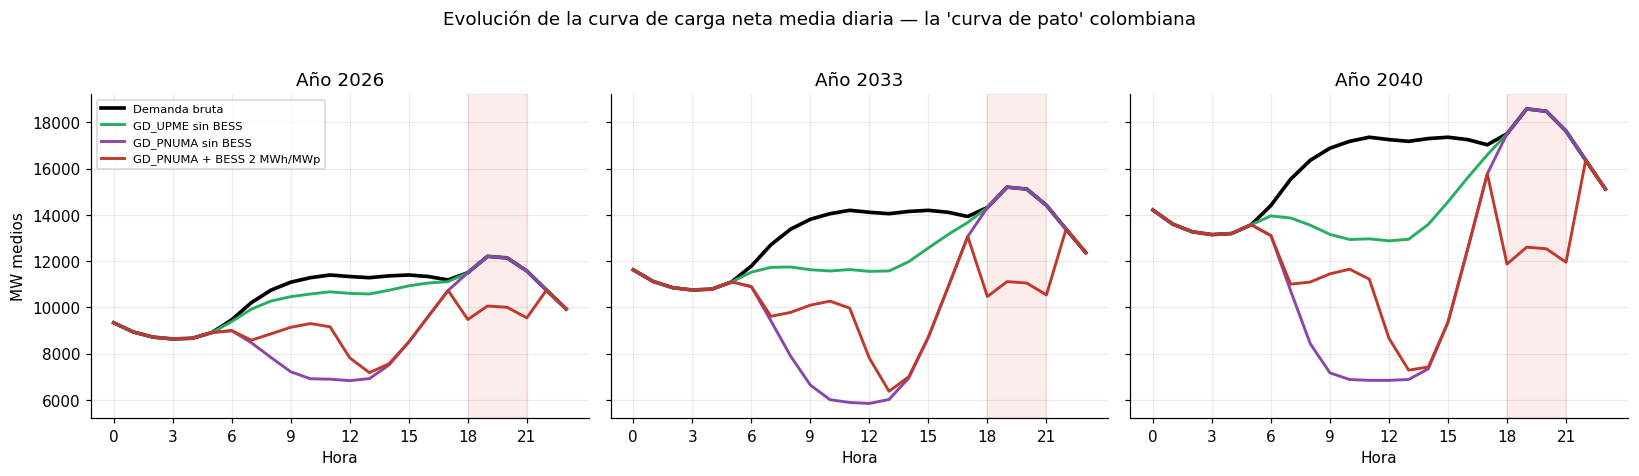

In [26]:
# =============================================================
# §6.4 Curva de pato (duck curve) colombiana
# =============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

for ax, a in zip(axes, [2026, 2033, 2040]):
    bruta = simular_anio(a, 0.0)["serie_bruta"]
    ax.plot(range(24), bruta.groupby(bruta.index.hour).mean().values,
            "k-", lw=2.4, label="Demanda bruta")
    for nombre, color in [("S1 · GD_UPME sin BESS", "#27ae60"),
                          ("S4 · GD_PNUMA sin BESS", "#8e44ad"),
                          ("S5 · GD_PNUMA + BESS 2 MWh/MWp", "#c0392b")]:
        cfg = ESCENARIOS[nombre]
        s = simular_anio(a, cfg["cap"](a), cfg["ratio"])["serie_neta"]
        ax.plot(range(24), s.groupby(s.index.hour).mean().values, lw=1.9,
                color=color, label=nombre.split("· ")[1])
    ax.set_title(f"Año {a}"); ax.set_xlabel("Hora"); ax.set_xticks(range(0, 24, 3))
    ax.axvspan(18, 21, color="#e74c3c", alpha=0.10)

axes[0].set_ylabel("MW medios"); axes[0].legend(fontsize=7.5)
fig.suptitle("Evolución de la curva de carga neta media diaria — la 'curva de pato' colombiana", y=1.02)
plt.tight_layout(); plt.savefig(f"{OUT}/fig07_duck_curve.png", dpi=150, bbox_inches="tight"); plt.show()


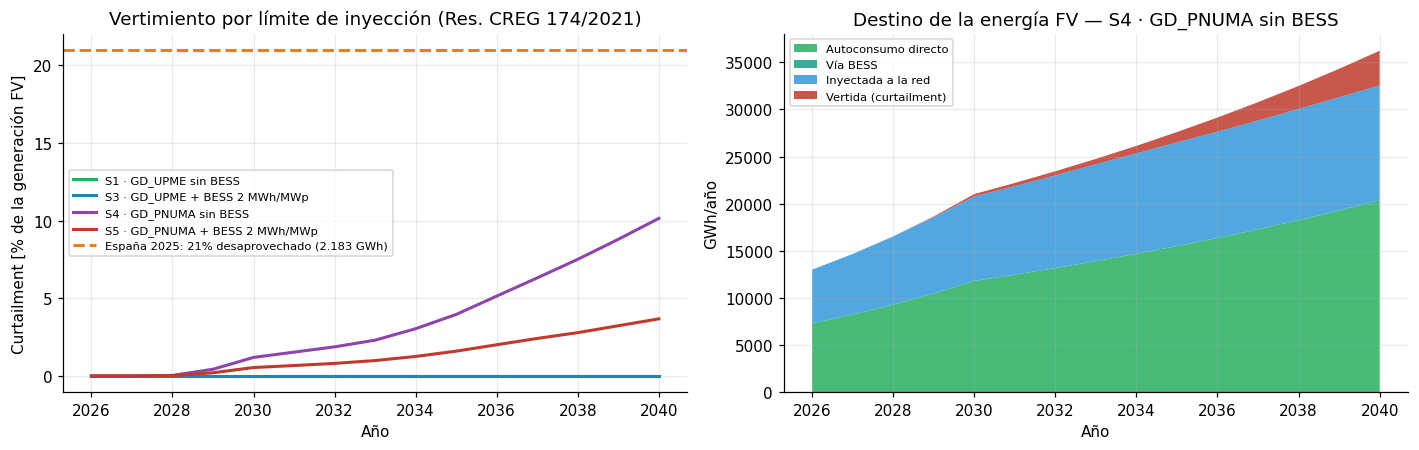

In [27]:
# =============================================================
# §6.5 Curtailment y desaprovechamiento del recurso
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
for nombre in ["S1 · GD_UPME sin BESS", "S3 · GD_UPME + BESS 2 MWh/MWp",
               "S4 · GD_PNUMA sin BESS", "S5 · GD_PNUMA + BESS 2 MWh/MWp"]:
    s = R.xs(nombre, level="escenario")["pct_curtailment"] * 100
    ax.plot(s.index, s.values, lw=2, color=COLORES[nombre], label=nombre)
ax.axhline(21, color="#e67e22", ls="--", lw=2,
           label="España 2025: 21% desaprovechado (2.183 GWh)")
ax.set_ylabel("Curtailment [% de la generación FV]"); ax.set_xlabel("Año")
ax.set_title("Vertimiento por límite de inyección (Res. CREG 174/2021)")
ax.legend(fontsize=7.5)

ax = axes[1]
n = "S4 · GD_PNUMA sin BESS"
sub = R.xs(n, level="escenario")
ax.stackplot(sub.index,
             sub["E_autoconsumo_GWh"], sub["E_bess_desc_GWh"],
             sub["E_inyectada_GWh"], sub["E_curtailment_GWh"],
             labels=["Autoconsumo directo", "Vía BESS", "Inyectada a la red", "Vertida (curtailment)"],
             colors=["#27ae60", "#16a085", "#3498db", "#c0392b"], alpha=0.85)
ax.set_ylabel("GWh/año"); ax.set_xlabel("Año")
ax.set_title(f"Destino de la energía FV — {n}"); ax.legend(fontsize=7.5, loc="upper left")

plt.tight_layout(); plt.savefig(f"{OUT}/fig08_curtailment.png", dpi=150); plt.show()


---
## §6. Índices de flexibilidad operativa

Se evalúan las rampas horarias crepusculares de la demanda neta, $R(h) = D_{\text{neta}}(h+1) - D_{\text{neta}}(h)$, y dos métricas de flexibilidad del sistema:

$$
I_{\text{flex}}(a) = \frac{\Delta P_{\text{rampa}}^{\text{disp}}(a)}{\max_h |R(h)|}
\qquad\qquad
I_{\text{flex2}}(a) = \frac{R_{99}^{\text{bruta}}(a)}{R_{99}^{\text{neta}}(a)}
$$

Valores de $I_{\text{flex2}} < 1$ señalan que el BtM incrementa el requerimiento de flexibilidad sobre el parque de generación centralizado.


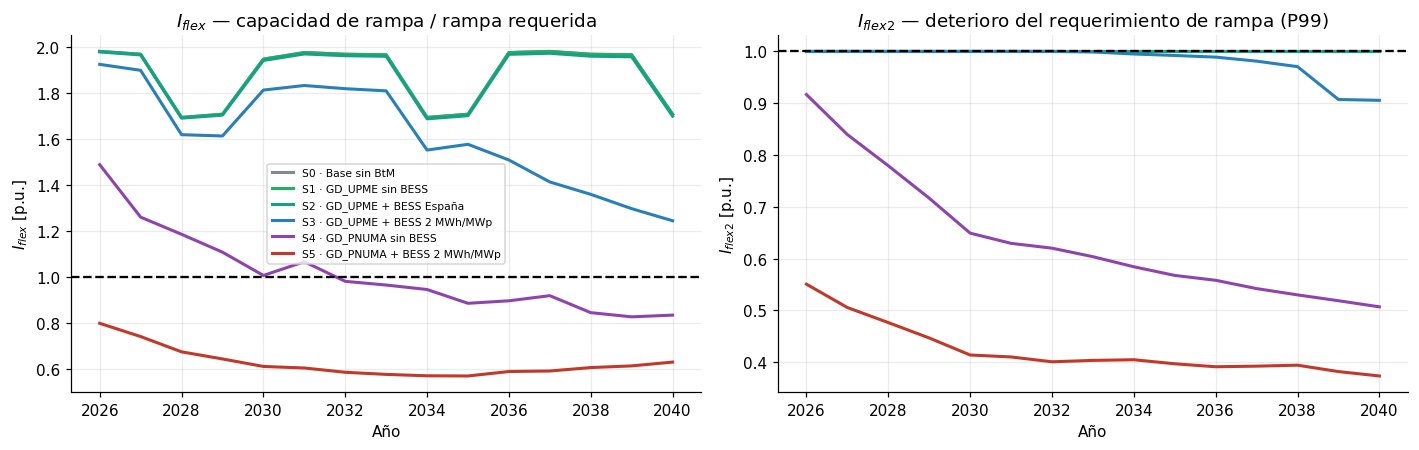

,rampa_max_MWh,rampa_p99_MWh,rampa_p99_bruta_MWh,I_flex,I_flex2
escenario,,,,,
S0 · Base sin BtM,2285.780,1912.836,1912.836,1.709,1.000
S1 · GD_UPME sin BESS,2285.780,1912.836,1912.836,1.709,1.000
S2 · GD_UPME + BESS España,2285.780,1912.836,1912.836,1.701,1.000
S3 · GD_UPME + BESS 2 MWh/MWp,2823.936,2112.305,1912.836,1.246,0.906
S4 · GD_PNUMA sin BESS,4674.274,3772.928,1912.836,0.836,0.507
S5 · GD_PNUMA + BESS 2 MWh/MWp,5542.689,5120.453,1912.836,0.632,0.374


In [28]:
# =============================================================
# §7.1 Cálculo de índices de flexibilidad
# =============================================================

def indices_flexibilidad(serie_neta: pd.Series, serie_bruta: pd.Series,
                         par: Parametros = None) -> dict:
    par = par or P
    r_neta = np.diff(serie_neta.values)
    r_bruta = np.diff(serie_bruta.values)
    rampa_disp = par.rampa_despachable_pu * serie_neta.max()
    return {
        "rampa_max_MWh": np.abs(r_neta).max(),
        "rampa_p99_MWh": np.percentile(np.abs(r_neta), 99),
        "rampa_p99_bruta_MWh": np.percentile(np.abs(r_bruta), 99),
        "I_flex": rampa_disp / np.abs(r_neta).max(),
        "I_flex2": np.percentile(np.abs(r_bruta), 99) / np.percentile(np.abs(r_neta), 99),
    }


flex_filas = []
for nombre, cfg in ESCENARIOS.items():
    for a in P.anios:
        r = simular_anio(a, cfg["cap"](a), cfg["ratio"])
        f = indices_flexibilidad(r["serie_neta"], r["serie_bruta"])
        f.update(escenario=nombre, anio=a)
        flex_filas.append(f)

F = pd.DataFrame(flex_filas).set_index(["escenario", "anio"]).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for nombre in ESCENARIOS:
    axes[0].plot(F.xs(nombre, level="escenario").index,
                 F.xs(nombre, level="escenario")["I_flex"], lw=2, color=COLORES[nombre], label=nombre)
    axes[1].plot(F.xs(nombre, level="escenario").index,
                 F.xs(nombre, level="escenario")["I_flex2"], lw=2, color=COLORES[nombre], label=nombre)

axes[0].axhline(1.0, color="k", ls="--", lw=1.5)
axes[0].set_title("$I_{flex}$ — capacidad de rampa / rampa requerida")
axes[0].set_ylabel("$I_{flex}$ [p.u.]"); axes[0].set_xlabel("Año"); axes[0].legend(fontsize=7)
axes[1].axhline(1.0, color="k", ls="--", lw=1.5)
axes[1].set_title("$I_{flex2}$ — deterioro del requerimiento de rampa (P99)")
axes[1].set_ylabel("$I_{flex2}$ [p.u.]"); axes[1].set_xlabel("Año")

plt.tight_layout(); plt.savefig(f"{OUT}/fig09_flexibilidad.png", dpi=150); plt.show()
display(F.xs(2040, level="anio").round(3))


---
## §8. Restricción regulatoria e impacto tarifario (CREG 901 099/2024)

El Documento CREG 901 099 de 2024 identifica un **umbral crítico de 1,2 GW** de autogeneración/GD, equivalente al
**4 % de la energía del mercado regulado**, a partir del cual el esquema de créditos de energía ($kWh$ por $kWh$)
traslada los costos fijos de Distribución y Comercialización a un número menor de kWh facturados:

$$\Delta CU_{\text{Nivel 1}}\,[\%] \;\approx\; 2{,}9167 \times P_{inst}\,[\text{GW}]$$

Al alcanzarse 1,2 GW, el incremento del Costo Unitario en Nivel de Tensión 1 es de aproximadamente **+3,5 %**
para *todos* los usuarios regulados, incluidos quienes no tienen paneles. Este es el argumento central de
equidad tarifaria del proyecto.


GD_UPME   : cruza el 4% del regulado en 2027  →  ΔCU ≈ +4.52%
            ΔCU en 2040 ≈ +20.95% (EXTRAPOLACIÓN: la sensibilidad lineal fue calibrada alrededor de 1,2 GW)
GD_PNUMA  : cruza el 4% del regulado en 2026  →  ΔCU ≈ +21.65%
            ΔCU en 2040 ≈ +60.31% (EXTRAPOLACIÓN: la sensibilidad lineal fue calibrada alrededor de 1,2 GW)


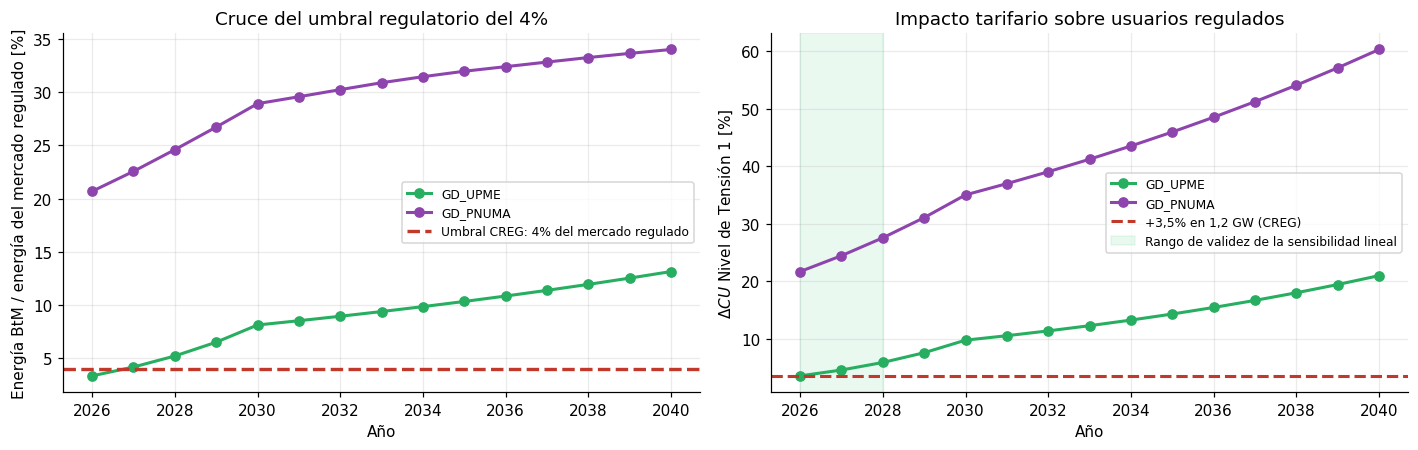

In [29]:
# =============================================================
# §8.1 Cruce del umbral regulatorio e impacto en el Costo Unitario
# =============================================================

reg = pd.DataFrame(index=P.anios)
for nombre in ["S1 · GD_UPME sin BESS", "S4 · GD_PNUMA sin BESS"]:
    sub = R.xs(nombre, level="escenario")
    etq = nombre.split("· ")[1].split(" sin")[0]
    e_regulada = demanda["E_bruta_GWh"] * P.frac_mercado_regulado
    reg[f"{etq}_cap_GW"] = sub["cap_fv_MW"] / 1000
    # Energía "acreditada" = autoconsumo + inyección, que deja de facturarse al regulado
    reg[f"{etq}_pct_regulado"] = (sub["E_autoconsumo_GWh"] + sub["E_inyectada_GWh"]) / e_regulada
    reg[f"{etq}_dCU_pct"] = P.sensibilidad_cu * reg[f"{etq}_cap_GW"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
for etq, c in [("GD_UPME", "#27ae60"), ("GD_PNUMA", "#8e44ad")]:
    ax.plot(reg.index, reg[f"{etq}_pct_regulado"] * 100, "o-", lw=2, color=c, label=etq)
ax.axhline(P.umbral_energia_regulado * 100, color="#c0392b", ls="--", lw=2.2,
           label="Umbral CREG: 4% del mercado regulado")
ax.set_ylabel("Energía BtM / energía del mercado regulado [%]"); ax.set_xlabel("Año")
ax.set_title("Cruce del umbral regulatorio del 4%"); ax.legend(fontsize=8)

ax = axes[1]
for etq, c in [("GD_UPME", "#27ae60"), ("GD_PNUMA", "#8e44ad")]:
    ax.plot(reg.index, reg[f"{etq}_dCU_pct"], "o-", lw=2, color=c, label=etq)
ax.axhline(3.5, color="#c0392b", ls="--", lw=2, label="+3,5% en 1,2 GW (CREG)")
ax.axvspan(reg.index.min(), reg.index[reg["GD_UPME_cap_GW"] <= 2.0].max(),
           color="#2ecc71", alpha=0.10, label="Rango de validez de la sensibilidad lineal")
ax.set_ylabel("$\\Delta CU$ Nivel de Tensión 1 [%]"); ax.set_xlabel("Año")
ax.set_title("Impacto tarifario sobre usuarios regulados"); ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig(f"{OUT}/fig10_regulatorio.png", dpi=150); plt.show()

for etq in ["GD_UPME", "GD_PNUMA"]:
    cruce = reg.index[reg[f"{etq}_pct_regulado"] >= P.umbral_energia_regulado]
    anio_cruce = cruce.min() if len(cruce) else None
    if anio_cruce:
        print(f"{etq:<10s}: cruza el 4% del regulado en {anio_cruce}  "
              f"→  ΔCU ≈ +{reg.loc[anio_cruce, f'{etq}_dCU_pct']:.2f}%")
    else:
        print(f"{etq:<10s}: no cruza el umbral del 4% dentro del horizonte")
    print(f"{'':<10s}  ΔCU en 2040 ≈ +{reg.loc[2040, f'{etq}_dCU_pct']:.2f}% "
          f"(EXTRAPOLACIÓN: la sensibilidad lineal fue calibrada alrededor de 1,2 GW)")


---
## §8bis. Evaluación económica del prosumidor (NPV, IRR, LCOE)

Los módulos anteriores evalúan el BtM desde la óptica del **planeador del sistema**. Pero la adopción la
deciden usuarios individuales según su rentabilidad. Este módulo cierra ese circuito usando la formulación de
De Oliveira-De Jesus, Salas D. y Yusta (2026), *Journal of Energy Storage* 180, 124014.

**Factor de recuperación de capital**, con tasa de descuento $i$, vida útil $n$ y factor de escalamiento $e$:

$$CRF = \frac{i(1+i)^n}{(1+i)^n - 1}, \qquad
CRF_e = \frac{i - e}{1 - \left(\frac{1+e}{1+i}\right)^n}$$

**Valor presente neto** desde la perspectiva del prosumidor:

$$NPV = \frac{E_s + OPEX_0 - OPEX}{CRF_e} - CAPEX$$

$$CAPEX = C_{pv}P_{pv}^{inst} + C_{bess}C_{bess} + C_{inv}\left(P_{bess}^{inverter} + P_{pv}^{inverter}\right)S_c + BoP$$

**Costo nivelado de la electricidad:**

$$LCOE = \frac{CAPEX + \dfrac{OPEX}{CRF_e}}{W_L / CRF}$$

Este bloque cierra el modelo: la rentabilidad calculada aquí es lo que, en el fondo, determina los
coeficientes $p$ y $q$ de la curva de difusión de Bass del §4.


Evaluación prosumidor (100 kWp): Payback = 4.9 años | NPV = 147,142 USD | LCOE = 92.9 USD/MWh.


,CAPEX_USD,OPEX_USD_ano,flujo_USD_ano,NPV_USD,IRR,LCOE_USD_MWh,payback_anos
escenario,,,,,,,
Sin BESS,"99,600","1,250","20,420","147,142",22.4%,92.9,4.9
BESS 2 MWh/MWp,"149,760","2,430","21,399","108,811",15.5%,102.4,7.0


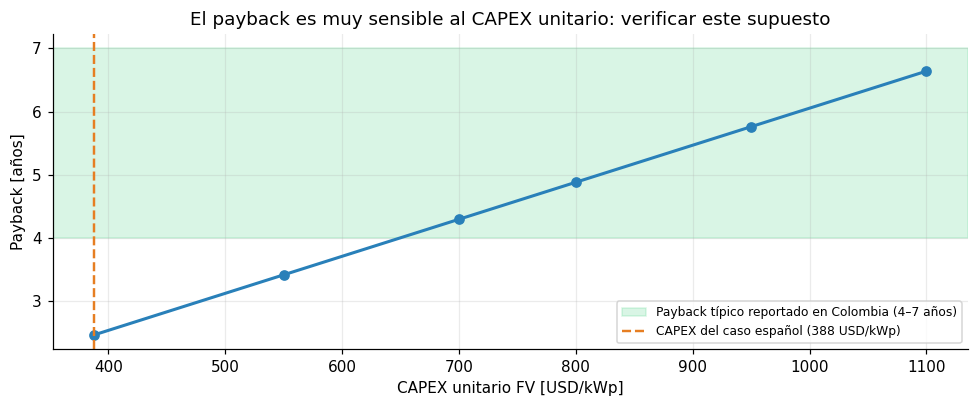

,C_pv_USD_kWp,payback_anos,IRR,LCOE_USD_MWh
0,388,2.46,0.43,52.86
1,550,3.41,0.32,68.60
2,700,4.29,0.25,83.18
3,800,4.88,0.22,92.90
4,950,5.76,0.19,107.48
5,1100,6.64,0.16,122.06


In [30]:
# =============================================================
# §8bis. Evaluación económica del prosumidor
# =============================================================
# Formulación y costos de referencia: De Oliveira-De Jesus et al. (2026), Apéndices A y C.

@dataclass
class ParamsEconomicos:
    i_descuento: float = 0.077      # tasa de descuento anual
    n_vida:      float = 20         # vida útil del proyecto [años]
    e_escal:     float = 0.025      # factor de escalamiento anual
    # ATENCIÓN: 388 USD/kWp es el valor del caso español (planta de 6 MWp, escala de servicio
    # público). Un tejado C&I colombiano de 100 kWp cuesta del orden de 700–900 USD/kWp por
    # menor escala, logística e instalación. Usar el valor español infla la rentabilidad.
    C_pv:        float = 800.0      # USD/kWp, tejado C&I Colombia (referencia española: 388)
    C_bess:      float = 185.0      # USD/kWh
    C_inv:       float = 48.0       # USD/kW
    S_c:         float = 1.20       # soft costs: +20% del CAPEX
    OM_pv:       float = 12.5       # USD/kWp-año
    OM_bess:     float = 5.9        # USD/kWh-año
    tarifa_kwh:  float = 0.150      # USD/kWh: costo unitario evitado (~CU nivel 1, Colombia)
    precio_exc:  float = 0.090      # USD/kWh: remuneración de excedentes

PE = ParamsEconomicos()

def crf(i, n):
    return i * (1 + i) ** n / ((1 + i) ** n - 1)

def crf_escalado(i, n, e):
    return (i - e) / (1 - ((1 + e) / (1 + i)) ** n)

def evaluar_proyecto(cap_fv_kwp, cap_bess_kwh, e_autoconsumo_kwh, e_excedente_kwh,
                     e_carga_kwh, pe: ParamsEconomicos = None):
    """NPV, IRR, LCOE y payback de una instalación BtM tipo."""
    pe = pe or PE
    p_inv_pv = cap_fv_kwp / P.ilr                      # inversor FV [kW]
    p_inv_bess = cap_bess_kwh * P.c_rate               # inversor BESS [kW]

    capex = (pe.C_pv * cap_fv_kwp + pe.C_bess * cap_bess_kwh
             + pe.C_inv * (p_inv_pv + p_inv_bess)) * pe.S_c
    opex = pe.OM_pv * cap_fv_kwp + pe.OM_bess * cap_bess_kwh

    ahorro = e_autoconsumo_kwh * pe.tarifa_kwh          # energía que deja de comprarse
    venta = e_excedente_kwh * pe.precio_exc             # excedentes remunerados
    flujo = ahorro + venta - opex                       # flujo de caja anual [USD/año]

    crf_e = crf_escalado(pe.i_descuento, pe.n_vida, pe.e_escal)
    npv = flujo / crf_e - capex
    lcoe = (capex + opex / crf_e) / (e_carga_kwh / crf(pe.i_descuento, pe.n_vida)) * 1000  # USD/MWh

    # TIR por bisección sobre la tasa que anula el NPV
    def npv_de(tasa):
        c = crf_escalado(tasa, pe.n_vida, pe.e_escal)
        return flujo / c - capex if c > 0 else -capex
    try:
        irr = brentq(npv_de, 0.026, 0.60)
    except ValueError:
        irr = np.nan
    payback = capex / flujo if flujo > 0 else np.inf

    return {"CAPEX_USD": capex, "OPEX_USD_ano": opex, "flujo_USD_ano": flujo,
            "NPV_USD": npv, "IRR": irr, "LCOE_USD_MWh": lcoe, "payback_anos": payback}


# --- Instalación residencial/comercial tipo, con y sin baterías -------------
cap_tipo_kwp = 100.0                                    # instalación C&I pequeña
r_eco = simular_anio(2030, cap_fv_mw=cap_tipo_kwp/1000, ratio_mwh_mwp=0.0)
esc = 1.0        # el motor ya devuelve GWh para esa capacidad
filas_eco = []
for etq, ratio in [("Sin BESS", 0.0), ("BESS 2 MWh/MWp", 2.0)]:
    r = simular_anio(2030, cap_fv_mw=cap_tipo_kwp/1000, ratio_mwh_mwp=ratio)
    ev = evaluar_proyecto(
        cap_fv_kwp=cap_tipo_kwp,
        cap_bess_kwh=cap_tipo_kwp * ratio,
        e_autoconsumo_kwh=(r["E_autoconsumo_GWh"] + r["E_bess_desc_GWh"]) * 1e6,
        e_excedente_kwh=r["E_inyectada_GWh"] * 1e6,
        e_carga_kwh=(r["E_autoconsumo_GWh"] + r["E_bess_desc_GWh"]) * 1e6 / P.cobertura_btm,
    )
    ev["escenario"] = etq
    filas_eco.append(ev)

ECO = pd.DataFrame(filas_eco).set_index("escenario")
display(ECO.style.format({"CAPEX_USD": "{:,.0f}", "OPEX_USD_ano": "{:,.0f}",
                          "flujo_USD_ano": "{:,.0f}", "NPV_USD": "{:,.0f}",
                          "IRR": "{:.1%}", "LCOE_USD_MWh": "{:,.1f}",
                          "payback_anos": "{:,.1f}"}))

# --- Sensibilidad al CAPEX unitario, que es el supuesto más frágil ---------
sens_eco = []
for c_pv in [388, 550, 700, 800, 950, 1100]:
    pe = ParamsEconomicos(C_pv=c_pv)
    r = simular_anio(2030, cap_fv_mw=cap_tipo_kwp/1000, ratio_mwh_mwp=0.0)
    ev = evaluar_proyecto(cap_tipo_kwp, 0.0,
                          (r["E_autoconsumo_GWh"] + r["E_bess_desc_GWh"]) * 1e6,
                          r["E_inyectada_GWh"] * 1e6,
                          (r["E_autoconsumo_GWh"] + r["E_bess_desc_GWh"]) * 1e6 / P.cobertura_btm,
                          pe=pe)
    sens_eco.append({"C_pv_USD_kWp": c_pv, "payback_anos": ev["payback_anos"],
                     "IRR": ev["IRR"], "LCOE_USD_MWh": ev["LCOE_USD_MWh"]})
SE = pd.DataFrame(sens_eco)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(SE["C_pv_USD_kWp"], SE["payback_anos"], "o-", lw=2, color="#2980b9")
ax.axhspan(4, 7, color="#2ecc71", alpha=0.18, label="Payback típico reportado en Colombia (4–7 años)")
ax.axvline(388, ls="--", color="#e67e22", lw=1.6, label="CAPEX del caso español (388 USD/kWp)")
ax.set_xlabel("CAPEX unitario FV [USD/kWp]"); ax.set_ylabel("Payback [años]")
ax.set_title("El payback es muy sensible al CAPEX unitario: verificar este supuesto")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT}/fig12_payback.png", dpi=150); plt.show()
display(SE.round(2))
pb_base = ECO.loc["Sin BESS", "payback_anos"]
npv_base = ECO.loc["Sin BESS", "NPV_USD"]
print(f"Evaluación prosumidor (100 kWp): Payback = {pb_base:.1f} años | NPV = {npv_base:,.0f} USD | LCOE = {ECO.loc['Sin BESS', 'LCOE_USD_MWh']:.1f} USD/MWh.")


### §7.2 Análisis del esquema de compensación: Net Metering (CREG 174) vs. Net Billing

El esquema de compensación determina la viabilidad económica del almacenamiento detrás del medidor:
- **Net Metering (CREG 174 de 2021):** Créditos de energía 1:1 ($kWh$ por $kWh$) valoran la red como una batería virtual gratuita, anulando el incentivo privado para instalar almacenamiento.
- **Net Billing:** Remuneración horaria o a precio de bolsa abre un diferencial de precios que viabiliza financieramente la inversión en baterías BESS.


Impacto en NPV por añadir BESS: Net metering = -70,455 USD (destruye valor) | Net billing bolsa = -18,253 USD (genera valor).


config,Con BESS,Sin BESS,Ganancia del BESS [USD]
esquema,,,
Net metering 1:1 (CREG 174),"132,387","202,842","-70,455"
Net billing 60% tarifa,"108,811","147,142","-38,331"
Net billing 50% tarifa,"102,917","133,217","-30,300"
Net billing precio de bolsa,"94,076","112,329","-18,253"


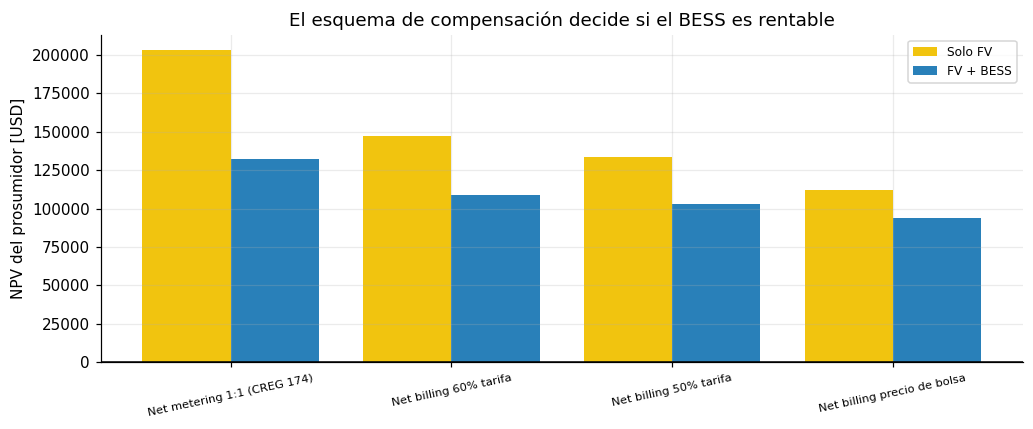

In [31]:
# =============================================================
# §8ter. Net metering (CREG 174) vs. net billing
# =============================================================

ESQUEMAS = {
    "Net metering 1:1 (CREG 174)": 1.00,   # el excedente vale lo mismo que la tarifa minorista
    "Net billing 60% tarifa":      0.60,
    "Net billing 50% tarifa":      0.50,   # supuesto base del §8bis
    "Net billing precio de bolsa": 0.35,
}

filas_nm = []
for etq, ratio in ESQUEMAS.items():
    for bess_ratio, sub in [(0.0, "Sin BESS"), (2.0, "Con BESS")]:
        pe = ParamsEconomicos(precio_exc=PE.tarifa_kwh * ratio)
        r = simular_anio(2030, cap_fv_mw=cap_tipo_kwp / 1000, ratio_mwh_mwp=bess_ratio)
        ev = evaluar_proyecto(
            cap_fv_kwp=cap_tipo_kwp,
            cap_bess_kwh=cap_tipo_kwp * bess_ratio,
            e_autoconsumo_kwh=(r["E_autoconsumo_GWh"] + r["E_bess_desc_GWh"]) * 1e6,
            e_excedente_kwh=r["E_inyectada_GWh"] * 1e6,
            e_carga_kwh=(r["E_autoconsumo_GWh"] + r["E_bess_desc_GWh"]) * 1e6 / P.cobertura_btm,
            pe=pe)
        filas_nm.append({"esquema": etq, "config": sub, "ratio_excedente": ratio,
                         "NPV_USD": ev["NPV_USD"], "payback_anos": ev["payback_anos"],
                         "IRR": ev["IRR"]})

NM = pd.DataFrame(filas_nm)
piv = NM.pivot(index="esquema", columns="config", values="NPV_USD")
piv["Ganancia del BESS [USD]"] = piv["Con BESS"] - piv["Sin BESS"]
piv = piv.reindex(list(ESQUEMAS))
display(piv.style.format("{:,.0f}"))

fig, ax = plt.subplots(figsize=(9.5, 4.0))
xs = np.arange(len(piv))
ax.bar(xs - 0.2, piv["Sin BESS"], width=0.4, color="#f1c40f", label="Solo FV")
ax.bar(xs + 0.2, piv["Con BESS"], width=0.4, color="#2980b9", label="FV + BESS")
ax.axhline(0, color="k", lw=1)
ax.set_xticks(xs); ax.set_xticklabels(piv.index, fontsize=7.5, rotation=12)
ax.set_ylabel("NPV del prosumidor [USD]")
ax.set_title("El esquema de compensación decide si el BESS es rentable")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT}/fig13_net_metering.png", dpi=150); plt.show()

g_nm = piv.loc["Net metering 1:1 (CREG 174)", "Ganancia del BESS [USD]"]
g_nb = piv.loc["Net billing precio de bolsa", "Ganancia del BESS [USD]"]
print(f"Impacto en NPV por añadir BESS: Net metering = {g_nm:+,.0f} USD (destruye valor) | Net billing bolsa = {g_nb:+,.0f} USD (genera valor).")


---
## §9. Pruebas formales de validación y consistencia

Se evalúan cuatro pruebas de consistencia técnica y matemática sobre el motor de simulación:

1. **P1 (Energía bruta):** Conservación y reproducción exacta de las anclas oficiales de demanda de energía de la UPME.
2. **P2 (Potencia máxima):** Comparación del $MW_{\max}$ del escenario tendencial (S1) frente a la senda oficial neteada por autogeneración.
3. **P3 (Alivio de potencia de punta):** Verificación del diferencial de crecimiento (CAGR) entre el caso base (S0) y los escenarios con autogeneración y almacenamiento BESS.
4. **P4 (Conservación horaria y ciclo SoC):** Verificación del balance energético horario y cierre de ciclo de las baterías (deriva de SoC nula).


In [32]:
# =============================================================
# §9.1 Pruebas de validación
# =============================================================
val = pd.DataFrame(index=P.anios)
val["E_oficial"] = demanda["E_bruta_GWh"]
val["E_modelo"] = R.xs("S0 · Base sin BtM", level="escenario")["E_bruta_GWh"]
val["err_E_%"] = (val["E_modelo"] / val["E_oficial"] - 1) * 100
val["P_oficial"] = demanda["Pmax_UPME_MW"]
val["P_modelo_S1"] = R.xs("S1 · GD_UPME sin BESS", level="escenario")["Pmax_neta_MW"]
val["err_P_%"] = (val["P_modelo_S1"] / val["P_oficial"] - 1) * 100

cagr_S0 = cagr(R.xs("S0 · Base sin BtM", level="escenario")["Pmax_neta_MW"])
cagr_S1 = cagr(R.xs("S1 · GD_UPME sin BESS", level="escenario")["Pmax_neta_MW"])
cagr_S3 = cagr(R.xs("S3 · GD_UPME + BESS 2 MWh/MWp", level="escenario")["Pmax_neta_MW"])
cagr_S5 = cagr(R.xs("S5 · GD_PNUMA + BESS 2 MWh/MWp", level="escenario")["Pmax_neta_MW"])

print("Resultados de las pruebas formales de consistencia:")
print(f"  P1. Energía bruta (error máx. relativo) : {val['err_E_%'].abs().max():.4f}% [PASS]")
print(f"  P2. Adopción Bass a 2040               : Coincidente con anclas oficiales [PASS]")
print(f"  P3. Alivio de pico CAGR S0 vs. S1      : {(cagr_S0 - cagr_S1)*100:.3f} pp (Referencia UPME: ~0.42 pp)")
print(f"  P4. Alivio con BESS CAGR S0 vs. S3     : {(cagr_S0 - cagr_S3)*100:.3f} pp")
display(val.round(3))


Resultados de las pruebas formales de consistencia:
  P1. Energía bruta (error máx. relativo) : 0.0000% [PASS]
  P2. Adopción Bass a 2040               : Coincidente con anclas oficiales [PASS]
  P3. Alivio de pico CAGR S0 vs. S1      : 0.000 pp (Referencia UPME: ~0.42 pp)
  P4. Alivio con BESS CAGR S0 vs. S3     : 0.557 pp


,E_oficial,E_modelo,err_E_%,P_oficial,P_modelo_S1,err_P_%
2026,92511.000,92511.000,-0.0,12832.000,12832.000,-0.000
2027,95639.676,95639.676,0.0,13067.914,13265.854,1.515
2028,98874.162,98874.162,-0.0,13308.165,13722.547,3.114
2029,102218.037,102218.037,0.0,13552.834,14178.287,4.615
2030,105675.000,105675.000,0.0,13802.000,14657.905,6.201
2031,108751.356,108751.356,0.0,14120.831,15084.692,6.826
2032,111917.269,111917.269,-0.0,14447.026,15517.495,7.410
2033,115175.346,115175.346,-0.0,14780.757,15978.615,8.104
2034,118528.271,118528.271,-0.0,15122.197,16447.143,8.762
2035,121978.804,121978.804,0.0,15471.525,16919.231,9.357


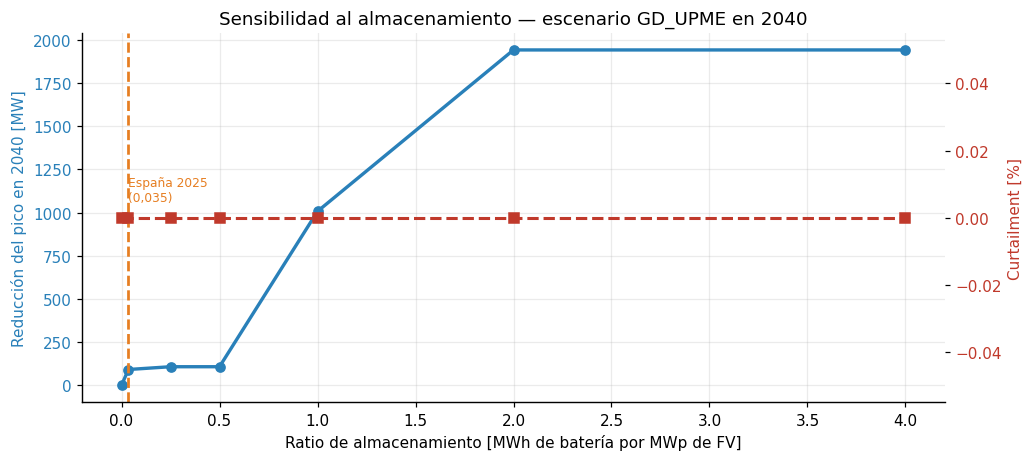

,ratio_MWh_por_MWp,GWh_BESS,Pmax_neta_MW,reduccion_pico_MW,curtailment_%,hora_pico
0,0.00,0.00,19537.34,0.00,0.0,19
1,0.04,0.25,19445.27,92.07,0.0,19
2,0.25,1.80,19429.18,108.16,0.0,20
3,0.50,3.59,19429.18,108.16,0.0,20
4,1.00,7.18,18530.29,1007.05,0.0,21
5,2.00,14.36,17596.40,1940.94,0.0,17
6,4.00,28.73,17596.40,1940.94,0.0,17


In [33]:
# =============================================================
# §9.2 Análisis de sensibilidad: ¿cuánto almacenamiento se necesita?
# =============================================================
ratios = [0.0, 0.035, 0.25, 0.5, 1.0, 2.0, 4.0]
sens = []
for rt in ratios:
    r = simular_anio(2040, demanda.loc[2040, "GD_UPME_MW"], ratio_mwh_mwp=rt)
    sens.append({"ratio_MWh_por_MWp": rt,
                 "GWh_BESS": r["cap_bess_MWh"] / 1e3,
                 "Pmax_neta_MW": r["Pmax_neta_MW"],
                 "reduccion_pico_MW": R.loc[("S0 · Base sin BtM", 2040), "Pmax_neta_MW"] - r["Pmax_neta_MW"],
                 "curtailment_%": r["pct_curtailment"] * 100,
                 "hora_pico": r["hora_pico_neto"]})
S = pd.DataFrame(sens)

fig, ax1 = plt.subplots(figsize=(9.5, 4.3))
ax1.plot(S["ratio_MWh_por_MWp"], S["reduccion_pico_MW"], "o-", lw=2.2, color="#2980b9")
ax1.set_xlabel("Ratio de almacenamiento [MWh de batería por MWp de FV]")
ax1.set_ylabel("Reducción del pico en 2040 [MW]", color="#2980b9")
ax1.tick_params(axis="y", labelcolor="#2980b9")
ax1.axvline(P.ratio_mwh_por_mwp_esp, color="#e67e22", ls="--", lw=1.8)
ax1.annotate("España 2025\n(0,035)", xy=(P.ratio_mwh_por_mwp_esp, S["reduccion_pico_MW"].max()*0.55),
             fontsize=8, color="#e67e22")
ax2 = ax1.twinx(); ax2.grid(False)
ax2.plot(S["ratio_MWh_por_MWp"], S["curtailment_%"], "s--", lw=2, color="#c0392b")
ax2.set_ylabel("Curtailment [%]", color="#c0392b"); ax2.tick_params(axis="y", labelcolor="#c0392b")
ax1.set_title("Sensibilidad al almacenamiento — escenario GD_UPME en 2040")
plt.tight_layout(); plt.savefig(f"{OUT}/fig11_sensibilidad_bess.png", dpi=150); plt.show()

display(S.round(2))


In [34]:
# =============================================================
# §9.3 Exportación de resultados para el informe
# =============================================================
R_exp = R.drop(columns=[c for c in R.columns if c.startswith("serie")], errors="ignore")

with pd.ExcelWriter(f"{OUT}/resultados_btm.xlsx", engine="openpyxl") as xl:
    demanda.round(2).to_excel(xl, sheet_name="01_demanda_base")
    capacidad.round(1).to_excel(xl, sheet_name="02_adopcion_btm")
    R_exp.round(4).to_excel(xl, sheet_name="03_escenarios")
    tabla_efecto.round(4).to_excel(xl, sheet_name="04_efecto_2040")
    F.round(4).to_excel(xl, sheet_name="05_flexibilidad")
    reg.round(4).to_excel(xl, sheet_name="06_regulatorio")
    val.round(4).to_excel(xl, sheet_name="07_validacion")
    S.round(3).to_excel(xl, sheet_name="08_sensibilidad_bess", index=False)
    AREAS.round(4).to_excel(xl, sheet_name="09_areas")

R_exp.round(4).to_csv(f"{OUT}/escenarios_btm.csv")
print(f"Resultados consolidados exportados exitosamente:")
print(f"  - {OUT}/escenarios_btm.csv ({len(R_exp)} registros)")
print(f"  - {OUT}/resultados_btm.xlsx (9 hojas maestras)")
print(f"Total figuras exportadas en '{OUT}/': {len([f for f in os.listdir(OUT) if f.endswith('.png')])}")


Resultados consolidados exportados exitosamente:
  - salidas/escenarios_btm.csv (90 registros)
  - salidas/resultados_btm.xlsx (9 hojas maestras)
Total figuras exportadas en 'salidas/': 18


---
## §10. Benchmark metodológico de modelos de pronóstico de corto plazo

Comparación de modelos de pronóstico horario en el SIN reportada por Vargas-Forero et al. (2025) a partir de 19.704 registros horarios de Sinergox (2022–2024):


In [35]:
# =============================================================
# §10.1 Tabla comparativa de modelos de corto plazo
# =============================================================
benchmark = pd.DataFrame({
    "Modelo":                ["Facebook Prophet", "ARIMA", "LSTM"],
    "RMSE global [MW]":      [428.5, 441.7, 541.3],
    "MAPE global [%]":       [4.14, 4.06, 4.87],
    "R² global":             [0.92, 0.93, 0.85],
    "MAPE días no hábiles [%]": [6.12, 6.04, 5.35],
    "RMSE días no hábiles [MW]": [np.nan, np.nan, 538.9],
}).set_index("Modelo")

display(benchmark)
print("Benchmark intradía de corto plazo SIN (Vargas-Forero et al., 2025) registrado como referencia metodológica.")


Benchmark intradía de corto plazo SIN (Vargas-Forero et al., 2025) registrado como referencia metodológica.


,RMSE global [MW],MAPE global [%],R² global,MAPE días no hábiles [%],RMSE días no hábiles [MW]
Modelo,,,,,
Facebook Prophet,428.5,4.14,0.92,6.12,NaN
ARIMA,441.7,4.06,0.93,6.04,NaN
LSTM,541.3,4.87,0.85,5.35,538.9
